In [8]:
import pycaret

In [9]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import math
import tqdm
from datetime import datetime

In [10]:
ukb = pd.read_csv('./NAFLD-CVD/data/ukb_final_data(260304)_addDeath.csv')

In [11]:
ukb_cvd = pd.read_csv("./NAFLD-CVD/data/algorithm_defined.csv", usecols=['eid','42000-0.0', '42002-0.0','42004-0.0','42006-0.0','42008-0.0', '42010-0.0', '42012-0.0'])
ukb_death = pd.read_csv("./NAFLD-CVD/data/ukb_death.csv")

In [12]:
ukb = ukb.merge(ukb_cvd, on=['eid'])
ukb = ukb.merge(ukb_death, on=['eid'])

In [13]:
ukb = ukb[[
    'eid',
    '21000-0.0',
    '31-0.0',
    '48-0.0_x',
 '20116-0.0', #Smoke status 
 '1249-0.0',
 '4079-0.0',
 '4080-0.0',
 '21001-0.0_x',
 '30080-0.0',
 '21022-0.0',
    '53-0.0',
    'FIB-4',
    'FLI',
    'BP_treated',
    'DM',
    'SAFE',
    'ASCVD_Risk',
    'FRS',
'Albumin','Alkaline_phosphatase','Alanine_aminotransferase','Apolipoprotein_A','Apolipoprotein_B',
'Aspartate_aminotransferase','Direct bilirubin','Urea','Calcium','Cholesterol','Creatinine','C-reactive_protein',
'Cystatin_C','Gamma_glutamyltransferase','Glucose','HbA1c','HDL','IGF-1','LDL_direct','Lipoprotein_A',
'Oestradiol','Phosphate','Rheumatoid_factor','SHBG','Total_bilirubin','Testosterone','Total_protein','Triglycerides',
'Urate','Vitamin_D','outcome','Dyslipidemia', 'MI_bi', 'STROKE_bi', 'STEMI_bi', 'NSTEMI_bi', 'ISCHAEMIC_bi', 'INTRACEREBRAL_HEMO_bi',
    'SUBARACHNOID_HEMO_bi','cardiac_death', '42000-0.0', '42002-0.0','42004-0.0','42006-0.0','42008-0.0',
    '42010-0.0', '42012-0.0','40000-0.0_y'
]]

ukb.columns = ['eid','ethnics','Sex','Waist','smoke_status','Past_tobacco',
               'Diastolic0','Systolic0','BMI','Platelet_count','Age', 
               'baseline','FIB4','FLI','BP_treated','DM', 'SAFE', 'ASCVD_Risk', 'FRS',
               'Albumin', 'Alkaline_phosphatase', 'Alanine_aminotransferase', 'Apolipoprotein_A', 
               'Apolipoprotein_B','Aspartate_aminotransferase', 'Direct bilirubin', 'Urea', 'Calcium',
               'Cholesterol', 'Creatinine', 'C-reactive_protein', 'Cystatin_C','Gamma_glutamyltransferase', 
               'Glucose', 'HbA1c', 'HDL', 'IGF-1','LDL_direct', 'Lipoprotein_A', 'Oestradiol', 'Phosphate',
               'Rheumatoid_factor', 'SHBG', 'Total_bilirubin', 'Testosterone','Total_protein', 'Triglycerides',
               'Urate', 'Vitamin_D','outcome',  'Dyslipidemia', 'MI_bi', 'STROKE_bi', 'STEMI_bi', 'NSTEMI_bi', 
               'ISCHAEMIC_bi', 'INTRACEREBRAL_HEMO_bi','SUBARACHNOID_HEMO_bi', 'cardiac_death','MIdate',
               'STEMIdate','NSTEMIdate','STROKEdate','ISCHAEMICdate', 'INTRACEREBRAL_HEMOdate',
               'SUBARACHNOID_HEMOdate','Death_date']

In [14]:
# Date lost to follow up
fu = pd.read_csv('./5_Health_outcome.csv', usecols=['eid', '191-0.0'])

In [15]:
ukb = ukb.merge(fu, how='inner', on='eid')

In [16]:
def calculate_date_difference(df, col1, col2):
    """
    Calculate the difference in days between two date columns in a DataFrame.
    Rows with NaN in either column are skipped.

    :param df: DataFrame containing the date columns
    :param col1: Name of the first date column
    :param col2: Name of the second date column
    :return: A Series with the difference in days
    """
    # Convert columns to datetime
    dates1 = pd.to_datetime(df[col1], errors='coerce')
    dates2 = pd.to_datetime(df[col2], errors='coerce')

    # Calculate difference
    difference = (dates2 - dates1).dt.days

    return difference

In [17]:
ukb.columns = ['eid', 'ethnics', 'Sex', 'Waist', 'smoke_status', 'Past_tobacco',
       'Diastolic0', 'Systolic0', 'BMI', 'Platelet_count', 'Age', 'baseline',
       'FIB4', 'FLI', 'BP_treated', 'DM', 'SAFE', 'ASCVD_Risk', 'FRS',
       'Albumin', 'Alkaline_phosphatase', 'Alanine_aminotransferase',
       'Apolipoprotein_A', 'Apolipoprotein_B', 'Aspartate_aminotransferase',
       'Direct bilirubin', 'Urea', 'Calcium', 'Cholesterol', 'Creatinine',
       'C-reactive_protein', 'Cystatin_C', 'Gamma_glutamyltransferase',
       'Glucose', 'HbA1c', 'HDL', 'IGF-1', 'LDL_direct', 'Lipoprotein_A',
       'Oestradiol', 'Phosphate', 'Rheumatoid_factor', 'SHBG',
       'Total_bilirubin', 'Testosterone', 'Total_protein', 'Triglycerides',
       'Urate', 'Vitamin_D', 'outcome', 'Dyslipidemia', 'MI_bi', 'STROKE_bi',
       'STEMI_bi', 'NSTEMI_bi', 'ISCHAEMIC_bi', 'INTRACEREBRAL_HEMO_bi',
       'SUBARACHNOID_HEMO_bi', 'cardiac_death', 'MIdate', 'STEMIdate',
       'NSTEMIdate', 'STROKEdate', 'ISCHAEMICdate', 'INTRACEREBRAL_HEMOdate',
       'SUBARACHNOID_HEMOdate', 'Death_date', 'fu_lost']

In [18]:
# Calculate the difference
ukb['death_diff'] = calculate_date_difference(ukb, 'baseline', 'Death_date')
ukb['mi_diff'] = calculate_date_difference(ukb, 'baseline', 'MIdate')
ukb['stemi_diff'] = calculate_date_difference(ukb, 'baseline', 'STEMIdate')
ukb['nstemi_diff'] = calculate_date_difference(ukb, 'baseline', 'NSTEMIdate')
ukb['stroke_diff'] = calculate_date_difference(ukb, 'baseline', 'STROKEdate')
ukb['ischaemic_diff'] = calculate_date_difference(ukb, 'baseline', 'ISCHAEMICdate')
ukb['instracerebral_diff'] = calculate_date_difference(ukb, 'baseline', 'INTRACEREBRAL_HEMOdate')
ukb['subarachnoid_diff'] = calculate_date_difference(ukb, 'baseline', 'SUBARACHNOID_HEMOdate')
ukb['fulost_diff'] = calculate_date_difference(ukb, 'baseline', 'fu_lost')

In [19]:
ukb['Calcium'] = ukb['Calcium']*4
ukb['Cholesterol'] = ukb['Cholesterol'] * 38.67 ## mg/dL
ukb['Glucose'] = ukb['Glucose'] * 18.018 ## mg/dL
ukb['HbA1c'] = (ukb['HbA1c'] / 10.929) + 2.1  ## %
ukb['HDL'] = ukb['HDL']*38.67 ## mg/dL
ukb['Total_bilirubin'] = ukb['Total_bilirubin'] * 0.05848 ## mg/dL
ukb['Total_protein'] = ukb['Total_protein'] / 10.0  ## g/dL
ukb['Triglycerides'] = ukb['Triglycerides'] * 88.57 ## mg/dL
ukb['LDL_direct'] = ukb['LDL_direct'] * 38.67
ukb['Albumin'] = ukb['Albumin'] / 10.0
ukb['C-reactive_protein'] = ukb['C-reactive_protein'] / 10.0
ukb['Creatinine'] = ukb['Creatinine'] / 88.42 ## mg/dL

In [20]:
ukb['NAFLD'] = 0
ukb['NAFLD'].loc[ukb['FLI'] >= 60] = 1

In [21]:
ukb['MASLD'] = 0
ukb['MASLD'].loc[
    (ukb['NAFLD'] == 1) &
    (
        ((ukb['Waist'].astype(float) >= 90.0) & ukb['Sex'] == 1 & ((str(ukb['ethnics']).startswith('3')) | (str(ukb['ethnics']).startswith('5')))) |
        ((ukb['Waist'].astype(float) >= 94.0) & ukb['Sex'] == 1 & ((str(ukb['ethnics']).startswith('1')) | (str(ukb['ethnics']).startswith('2')) | (str(ukb['ethnics']).startswith('4')) | (str(ukb['ethnics']).startswith('6')) | (str(ukb['ethnics']).startswith('-')))) |
        ((ukb['Waist'].astype(float) >= 80.0) & ukb['Sex'] == 0 & ((str(ukb['ethnics']).startswith('3')) | (str(ukb['ethnics']).startswith('5')))) |
        ((ukb['Waist'].astype(float) >= 80.0) & ukb['Sex'] == 1 & ((str(ukb['ethnics']).startswith('1')) | (str(ukb['ethnics']).startswith('2')) | (str(ukb['ethnics']).startswith('4')) | (str(ukb['ethnics']).startswith('6')) | (str(ukb['ethnics']).startswith('-')))) |
        ((ukb['Systolic0'].astype(float) >= 130) | (ukb['Diastolic0'].astype(float) >= 85) | (ukb['BP_treated'] == 1)) |
        ((ukb['Triglycerides'].astype(float) >= 150) | (ukb['Dyslipidemia'] == 1)) |
        ((ukb['HDL'].astype(float) <= 40) & (ukb['Sex'] == 1)) |
        ((ukb['HDL'].astype(float) <= 50) & (ukb['Sex'] == 0)) |
        ((ukb['BMI'].astype(float) >= 23.0) & ((str(ukb['ethnics']).startswith('3')) | (str(ukb['ethnics']).startswith('5')))) |
        ((ukb['BMI'].astype(float) >= 25.0) & ((str(ukb['ethnics']).startswith('1')) | (str(ukb['ethnics']).startswith('2')) | (str(ukb['ethnics']).startswith('4')) | (str(ukb['ethnics']).startswith('6')) | (str(ukb['ethnics']).startswith('-'))))
    )
] = 1

In [24]:
ukb['ethnics'] = ukb['ethnics'].astype(str)
ukb.loc[ukb['ethnics'].str.startswith('1'), 'ethnics'] = '1'
ukb.loc[ukb['ethnics'].str.startswith('2'), 'ethnics'] = '2'
ukb.loc[ukb['ethnics'].str.startswith('3'), 'ethnics'] = '3'
ukb.loc[ukb['ethnics'].str.startswith('4'), 'ethnics'] = '4'
ukb.loc[ukb['ethnics'].str.startswith('5'), 'ethnics'] = '5'
ukb.loc[ukb['ethnics'].str.startswith('6'), 'ethnics'] = '6'

In [25]:
def combine_year_month_to_date(df, year_col, month_col, day='01'):
    """
    Combine year and month columns (in float format) into a single date column.

    :param df: DataFrame containing the year and month columns
    :param year_col: Name of the column containing the year
    :param month_col: Name of the column containing the month
    :param day: The day to use in the date (default is '01')
    :return: A Series with the combined date in 'YYYY-MM-DD' format
    """
    # Convert year and month to integer, then to string
    year_str = df[year_col].dropna().apply(lambda x: str(int(x)))
    month_str = df[month_col].dropna().apply(lambda x: f'{int(x):02}')

    # Combine year, month, and day strings
    combined_date_str = year_str + '-' + month_str + '-' + day

    # Convert to datetime
    combined_date = pd.to_datetime(combined_date_str, errors='coerce', format='%Y-%m-%d')

    return combined_date

In [26]:
features = ['Age', 'Sex', 'Waist', 'smoke_status', 'Diastolic0',
            'Systolic0', 'BMI', 'Platelet_count', 'BP_treated', 'DM',
            'Albumin', 'Alanine_aminotransferase', 
            'Aspartate_aminotransferase',
            'Calcium', 'Cholesterol', 'Creatinine',
            'C-reactive_protein', 'Gamma_glutamyltransferase',
            'Glucose', 'HbA1c', 'HDL', 'LDL_direct', 
            'Total_bilirubin', 'Total_protein',
            'Triglycerides'
           ]

In [27]:
mask_fli = (ukb['MASLD'] >= 1)

# Filter the DataFrame based on FLI mask
ukb_filtered = ukb[mask_fli]
ukb_filtered.reset_index(drop=True, inplace=True)

In [28]:
ukb_data = ukb_filtered[features+['outcome']+
                        ['ethnics','eid','SAFE','ASCVD_Risk','FRS','FIB4']+
                        ['death_diff','mi_diff','stroke_diff','stemi_diff','nstemi_diff', 
                         'ischaemic_diff', 'instracerebral_diff','subarachnoid_diff','fulost_diff']]

In [29]:
ukb_data.columns

Index(['Age', 'Sex', 'Waist', 'smoke_status', 'Diastolic0', 'Systolic0', 'BMI',
       'Platelet_count', 'BP_treated', 'DM', 'Albumin',
       'Alanine_aminotransferase', 'Aspartate_aminotransferase', 'Calcium',
       'Cholesterol', 'Creatinine', 'C-reactive_protein',
       'Gamma_glutamyltransferase', 'Glucose', 'HbA1c', 'HDL', 'LDL_direct',
       'Total_bilirubin', 'Total_protein', 'Triglycerides', 'outcome',
       'ethnics', 'eid', 'SAFE', 'ASCVD_Risk', 'FRS', 'FIB4', 'death_diff',
       'mi_diff', 'stroke_diff', 'stemi_diff', 'nstemi_diff', 'ischaemic_diff',
       'instracerebral_diff', 'subarachnoid_diff', 'fulost_diff'],
      dtype='object')

#### 과거력이 있는사람 제외 (음수로 나타남)

In [31]:
## 각각 Event가 하나라도 이전에 있었던 사람들 제외
ukb_data = ukb_data.query('index not in @ukb_data.query("death_diff < 0 or mi_diff < 0 or stroke_diff < 0 or stemi_diff < 0 or nstemi_diff < 0 or ischaemic_diff < 0 or instracerebral_diff < 0 or subarachnoid_diff < 0").index.tolist()')

In [33]:
## 각각 Event가 하나라도 이전에 있었던 사람들 제외
ukb_data2 = ukb_data.query('index not in @ukb_data.query("death_diff < 0 or mi_diff < 0 or stroke_diff < 0 or stemi_diff < 0 or nstemi_diff < 0 or ischaemic_diff < 0 or instracerebral_diff < 0 or subarachnoid_diff < 0").index.tolist()')
ukb_data2 = ukb_data2.query('index not in @ukb_data.query("outcome == 0 and death_diff == death_diff").index.tolist()')

In [35]:
ukb_data2.outcome.value_counts()

outcome
0    36017
1     3674
Name: count, dtype: int64

In [37]:
ukb_data2.reset_index(drop=True, inplace=True)

In [38]:
import pandas as pd
from xgboost import XGBClassifier
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Add region

In [39]:
region = pd.read_csv('./NAFLD-CVD/data/region.csv')

In [40]:
# Creating Python lists for the coding numbers based on the regions

england = [
    11012, 11021, 11011, 11008, 11024, 11020, 11018, 11010, 11016, 
    11001, 11017, 11009, 11013, 11002, 11007, 11014, 10003, 11006, 
    11025, 11026, 11027, 11028
]
scotland = [11005, 11004]
wales = [11003, 11022, 11023]

In [41]:
# Function to determine the region based on the code
def determine_region(code):
    if code in england:
        return 'England'
    elif code in scotland:
        return 'Scotland'
    elif code in wales:
        return 'Wales'
    else:
        return 'Unknown'

# Create a new column 'region' based on the values of '54-0.0'
region['region'] = region['54-0.0'].apply(determine_region)

In [43]:
ukb_data2 = ukb_data2.merge(region[['eid', 'region']], on =['eid'])

In [47]:
ukb_data2['ethnics'] = ukb_data2['ethnics'].astype(str)

# add hand grip

In [48]:
hg = pd.read_csv("./hand_grip.csv")

In [49]:
hg = hg[['eid','46-0.0','47-0.0']]

In [50]:
hg.columns = ['eid','hand_grip_left', 'hand_grip_right']

In [52]:
ukb_data2 = ukb_data2.merge(hg, on=['eid'])

In [54]:
ukb_masld2 = ukb_data2.copy()

In [56]:
# Ethinicity White vs Non-white binary
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('1'), 'ethnics'] = '1' #White
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('2'), 'ethnics'] = '2' #Non-white
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('3'), 'ethnics'] = '2' #Asian or Asian British
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('4'), 'ethnics'] = '2' #Black or Black British
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('5'), 'ethnics'] = '2' #Chinese
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('6'), 'ethnics'] = '2' #Other ethnic group
ukb_masld2.loc[ukb_masld2['ethnics'].str.startswith('-'), 'ethnics'] = '2'

# Smoking status - Binary
ukb_masld2.loc[ukb_masld2['smoke_status']== 0, 'smoke_status'] = 0 # Never
ukb_masld2.loc[ukb_masld2['smoke_status']== 1, 'smoke_status'] = 0 # Previous
ukb_masld2.loc[ukb_masld2['smoke_status']== 2, 'smoke_status'] = 1 # Currunt
ukb_masld2.loc[ukb_masld2['smoke_status']== -3, 'smoke_status'] = 0 # NA

In [61]:
def select_minimum(df, cols):
    return df[cols].min(axis=1)

# Assuming df1 and df2 are your two DataFrames
cols_to_compare = ['death_diff', 'stroke_diff', 'mi_diff']
ukb_masld['min_diff'] = select_minimum(ukb_masld, cols_to_compare)

In [62]:
ukb_masld.min_diff.median()/365.0

8.128767123287671

In [63]:
before = ukb_masld.query('min_diff < 0').eid.tolist()

In [66]:
ukb_masld2['min_diff'] = select_minimum(ukb_masld2, cols_to_compare)
before = ukb_masld2.query('min_diff < 0').eid.tolist()
ukb_masld2 = ukb_masld2.query("eid not in @before")

# IECV with Redifined outcome (10yrs)

In [68]:
# Example usage
# Assuming df is your DataFrame and 'time_to_event' is your column of interest

def create_redefined_outcome(df, time_column, original_outcome_column, cutoff=3650):
    """
    Create a new column 'redefined_outcome' in the DataFrame.
    The redefined outcome is 0 if the original outcome is 1 and 
    the time value exceeds 3650; otherwise, it remains as the original outcome.

    :param df: DataFrame to process.
    :param time_column: The name of the column with the time until the event.
    :param original_outcome_column: The name of the original outcome column.
    :return: DataFrame with the new 'redefined_outcome' column.
    """
    df['redefined_outcome'] = df[original_outcome_column]
    condition = (df[original_outcome_column] == 1) & (df[time_column] > cutoff)
    df.loc[condition, 'redefined_outcome'] = 0
    return df

redefined_ukb_data = create_redefined_outcome(ukb_masld, 'min_diff', 'outcome', 3650)
#redefined_koges_data = create_redefined_outcome(koges_data, 'min_diff', 'outcome', 3650)

In [69]:
redefined_ukb_data2 = create_redefined_outcome(ukb_masld2, 'min_diff', 'outcome', 3650)

In [72]:
selected_var = ['Age',
 'Sex',
 'Waist',
 'smoke_status',
 'Systolic0',
 'Diastolic0',
 'BMI',
 'Platelet_count',
 'DM',
 'Albumin',
 'Alanine_aminotransferase',
 'Aspartate_aminotransferase',
 'Cholesterol',
 'Creatinine',
 'Gamma_glutamyltransferase',
 'HbA1c',
 'HDL',
 'Total_bilirubin',
 'Total_protein',
 'Triglycerides',
 'hand_grip_left',
 'hand_grip_right',
    'ethnics', 'BP_treated',  'Glucose', 'LDL_direct']

In [73]:
def train_test_comfort(train_data, external_data, features=selected_var,
                       test_size=0.2, outcome_col='outcome', random_state=42):
    """
    Preprocessing pipeline with strict separation: all imputation and scaling
    parameters are fitted exclusively on the training set and applied
    (transform-only) to the validation and external test sets.
    """
    # Filter features and target
    X = train_data[features]
    y = train_data[outcome_col]

    # Define column groups
    categorical_cols = ['Sex', 'smoke_status', 'DM', 'BP_treated']
    numerical_cols = list(set(features) - set(categorical_cols))

    # =========================================================
    # STEP 1: Split indices BEFORE any fitting
    # =========================================================
    train_idx, val_idx = train_test_split(
        train_data.index, test_size=test_size, random_state=random_state
    )

    # Subset raw (pre-imputation) features by split
    X_train_raw = X.loc[train_idx]
    X_val_raw   = X.loc[val_idx]
    y_train     = y.loc[train_idx]
    y_val       = y.loc[val_idx]

    # =========================================================
    # STEP 2: Fit imputers EXCLUSIVELY on training rows
    # =========================================================
    # Numerical imputer
    numerical_imputer = IterativeImputer(random_state=random_state)
    numerical_imputer.fit(X_train_raw[numerical_cols])

    X_train_num_imputed = numerical_imputer.transform(X_train_raw[numerical_cols])
    X_val_num_imputed   = numerical_imputer.transform(X_val_raw[numerical_cols])

    # Categorical imputer
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    categorical_imputer.fit(X_train_raw[categorical_cols])

    X_train_cat_imputed = categorical_imputer.transform(X_train_raw[categorical_cols])
    X_val_cat_imputed   = categorical_imputer.transform(X_val_raw[categorical_cols])

    # Back to DataFrames (preserve indices)
    X_train_num_df = pd.DataFrame(X_train_num_imputed, columns=numerical_cols,
                                  index=train_idx)
    X_val_num_df   = pd.DataFrame(X_val_num_imputed,   columns=numerical_cols,
                                  index=val_idx)
    X_train_cat_df = pd.DataFrame(X_train_cat_imputed, columns=categorical_cols,
                                  index=train_idx)
    X_val_cat_df   = pd.DataFrame(X_val_cat_imputed,   columns=categorical_cols,
                                  index=val_idx)

    X_train_imputed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
    X_val_imputed   = pd.concat([X_val_num_df,   X_val_cat_df],   axis=1)

    # =========================================================
    # STEP 3: Fit scaler EXCLUSIVELY on training rows
    # =========================================================
    scaler = StandardScaler()
    scaler.fit(X_train_imputed[numerical_cols])

    X_train = X_train_imputed.copy()
    X_val   = X_val_imputed.copy()
    X_train[numerical_cols] = scaler.transform(X_train_imputed[numerical_cols])
    X_val[numerical_cols]   = scaler.transform(X_val_imputed[numerical_cols])

    # =========================================================
    # STEP 4: External (Scotland/Wales) test set — TRANSFORM ONLY
    # =========================================================
    X_external = external_data[features]
    y_external = external_data[outcome_col].reset_index(drop=True)

    X_ext_num_imputed = numerical_imputer.transform(X_external[numerical_cols])
    X_ext_cat_imputed = categorical_imputer.transform(X_external[categorical_cols])

    X_ext_num_df = pd.DataFrame(X_ext_num_imputed, columns=numerical_cols)
    X_ext_cat_df = pd.DataFrame(X_ext_cat_imputed, columns=categorical_cols)
    X_external_imputed = pd.concat([X_ext_num_df, X_ext_cat_df], axis=1)

    X_external_scaled = X_external_imputed.copy()
    X_external_scaled[numerical_cols] = scaler.transform(
        X_external_imputed[numerical_cols]
    )

    return (X_train, y_train, X_val, y_val,
            X_external_scaled, y_external, train_idx, val_idx)

In [74]:
random_state = 777

In [75]:
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from sksurv.metrics import cumulative_dynamic_auc

# =============================================
# 1. time, event 변수 생성 (split 전에 수행)
# =============================================
def create_survival_vars(df, outcome_col='outcome', 
                         event_time_col='min_diff', 
                         fulost_col='fulost_diff'):
    """
    time_days: baseline → 이벤트 또는 censoring까지 일수
    event: 1=CVD 발생, 0=censored
    """
    df = df.copy()
    
    df['event'] = df[outcome_col].astype(int)
    
    df['time_days'] = np.where(
        df[outcome_col] == 1,
        df[event_time_col],                          # CVD 발생자 → 이벤트까지 시간
        np.where(
            df[fulost_col].notna() & (df[fulost_col] > 0),
            df[fulost_col],                           # 중도 탈락자 → 탈락까지 시간
            3650                                      # 나머지 → 10년 cap
        )
    )
    
    df['time_years'] = df['time_days'] / 365.25
    
    return df


# =============================================
# 2. 기존 train_test_comfort에 time 정보 추가
# =============================================

train_data = create_survival_vars(redefined_ukb_data2.query("region == 'England'").reset_index())
external_data = create_survival_vars(redefined_ukb_data2.query("region != 'England'").reset_index())

X_train, y_train, X_val, y_val, X_external, y_external, train_idx, val_idx = train_test_comfort(
    redefined_ukb_data2.query("region == 'England'").reset_index(), 
    redefined_ukb_data2.query("region != 'England'").reset_index(),
    selected_var,
    test_size=0.2, outcome_col='redefined_outcome', random_state=random_state)

time_train = train_data.loc[train_idx, 'time_years'].values
event_train = train_data.loc[train_idx, 'event'].values

time_val = train_data.loc[val_idx, 'time_years'].values
event_val = train_data.loc[val_idx, 'event'].values

time_ext = external_data['time_years'].values
event_ext = external_data['event'].values

In [76]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=random_state, n_neighbors=3)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

In [77]:
# Training the Random Forest model
model = XGBClassifier(
    #scale_pos_weight=(sum(y_train == 0) / sum(y_train == 1)),
    random_state=random_state,
    eval_metric='auc', 
    learning_rate=0.05,  # Lower learning rate
    n_estimators=200,    # Can reduce if overfitting
    max_depth=4,         # Lower max depth
    min_child_weight=7,  # Increase if needed
    gamma=0.1,           # Increase if needed
    subsample=0.75,       # Less than 1.0
    colsample_bytree=0.7, # Less than 1.0
    reg_alpha=0.5,
    reg_lambda=7.0,
)

In [79]:
model.fit(
    X_train_res, y_train_res,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=7, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
# =============================================
# 1. Calibration: validation set으로 한 번만 fit
# =============================================
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
calibrated_model.fit(X_val, y_val)  # validation set으로만 fit

# 모든 데이터셋에 동일한 calibration 적용
pred_train_cal = calibrated_model.predict_proba(X_train)[:, 1]
pred_val_cal = calibrated_model.predict_proba(X_val)[:, 1]
pred_ext_cal = calibrated_model.predict_proba(X_external)[:, 1]


# =============================================
# 2. Calibration Metrics
# =============================================
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

def compute_calibration_metrics(y_true, y_pred):
    eps = 1e-7
    
    # Brier Score
    brier = brier_score_loss(y_true, y_pred)
    
    # Calibration-in-the-large (CITL)
    mean_obs = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    citl = (np.log(np.clip(mean_obs, eps, 1-eps) / (1 - np.clip(mean_obs, eps, 1-eps))) -
            np.log(np.clip(mean_pred, eps, 1-eps) / (1 - np.clip(mean_pred, eps, 1-eps))))
    
    # Calibration Slope
    logit_pred = np.log(np.clip(y_pred, eps, 1-eps) / (1 - np.clip(y_pred, eps, 1-eps)))
    X_cal = sm.add_constant(logit_pred)
    logit_model = sm.Logit(y_true, X_cal).fit(disp=0)
    cal_slope = logit_model.params[1]
    cal_intercept = logit_model.params[0]
    
    return {
        'brier': brier,
        'citl': citl,
        'cal_slope': cal_slope,
        'cal_intercept': cal_intercept,
        'mean_obs': mean_obs,
        'mean_pred': mean_pred
    }

# 95% CI (Bootstrap)
def calibration_with_ci(y_true, y_pred, n_boot=1000, seed=42):
    np.random.seed(seed)
    point = compute_calibration_metrics(y_true, y_pred)
    
    boot_brier, boot_citl, boot_slope = [], [], []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        try:
            m = compute_calibration_metrics(y_true[idx], y_pred[idx])
            boot_brier.append(m['brier'])
            boot_citl.append(m['citl'])
            boot_slope.append(m['cal_slope'])
        except:
            continue
    
    point['brier_ci'] = (np.percentile(boot_brier, 2.5), np.percentile(boot_brier, 97.5))
    point['citl_ci'] = (np.percentile(boot_citl, 2.5), np.percentile(boot_citl, 97.5))
    point['slope_ci'] = (np.percentile(boot_slope, 2.5), np.percentile(boot_slope, 97.5))
    return point


# =============================================
# 3. 결과 출력
# =============================================
# print("=" * 75)
# print("Calibration Metrics (with 95% CI)")
# print("=" * 75)

for name, y, p in [
    ('Train', y_train.values, pred_train_cal),
    ('Validation', y_val.values, pred_val_cal),
    ('Test', y_external.values, pred_ext_cal),
]:
    r = calibration_with_ci(y, p)
    # print(f"\n--- {name} ---")
    # print(f"  Brier Score:  {r['brier']:.4f} ({r['brier_ci'][0]:.4f}–{r['brier_ci'][1]:.4f})")
    # print(f"  CITL:         {r['citl']:.4f} ({r['citl_ci'][0]:.4f}–{r['citl_ci'][1]:.4f})")
    # print(f"  Cal. Slope:   {r['cal_slope']:.4f} ({r['slope_ci'][0]:.4f}–{r['slope_ci'][1]:.4f})")
    # print(f"  Mean Obs:     {r['mean_obs']:.4f}  |  Mean Pred: {r['mean_pred']:.4f}")


# =============================================
# 4. Enhanced Calibration Plot (with metrics)
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    ('Train', y_train.values, pred_train_cal),
    ('Validation', y_val.values, pred_val_cal),
    ('Test', y_external.values, pred_ext_cal),
]
colors = ['black', 'red', 'green']

for idx, (name, y, p) in enumerate(datasets):
    ax = axes[idx]
    m = compute_calibration_metrics(y, p)
    
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy='quantile')
    
    ax.plot(mean_pred, frac_pos, 'o-', color=colors[idx], linewidth=2, markersize=6)
    
    # 데이터 범위에 맞춰 ideal line
    max_val = max(max(mean_pred), max(frac_pos)) * 1.2
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Ideal')
    
    textstr = (f"Brier: {m['brier']:.4f}\n"
               f"CITL: {m['citl']:.4f}\n"
               f"Slope: {m['cal_slope']:.3f}")
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Observed Proportion', fontsize=12)
    ax.set_title(f'{name} Set', fontsize=13)
    ax.set_xlim([0, max_val])
    ax.set_ylim([0, max_val])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_with_metrics.png', dpi=300, bbox_inches='tight')
#plt.show()

# C-index, Time-dependence AUC

In [81]:
from lifelines.utils import concordance_index

In [82]:
redefined_ukb_data2.columns

Index(['Age', 'Sex', 'Waist', 'smoke_status', 'Diastolic0', 'Systolic0', 'BMI',
       'Platelet_count', 'BP_treated', 'DM', 'Albumin',
       'Alanine_aminotransferase', 'Aspartate_aminotransferase', 'Calcium',
       'Cholesterol', 'Creatinine', 'C-reactive_protein',
       'Gamma_glutamyltransferase', 'Glucose', 'HbA1c', 'HDL', 'LDL_direct',
       'Total_bilirubin', 'Total_protein', 'Triglycerides', 'outcome',
       'ethnics', 'eid', 'SAFE', 'ASCVD_Risk', 'FRS', 'FIB4', 'death_diff',
       'mi_diff', 'stroke_diff', 'stemi_diff', 'nstemi_diff', 'ischaemic_diff',
       'instracerebral_diff', 'subarachnoid_diff', 'fulost_diff', 'region',
       'hand_grip_left', 'hand_grip_right', 'min_diff', 'redefined_outcome'],
      dtype='object')

M-CARD AI: mean TD-AUC = 0.7848 (0.7537–0.8252)
  1yr: 0.8493 (0.7622–0.9203)
  2yr: 0.8076 (0.7359–0.8719)
  3yr: 0.8217 (0.7727–0.8688)
  4yr: 0.8058 (0.7555–0.8520)
  5yr: 0.7964 (0.7488–0.8382)
  6yr: 0.7819 (0.7411–0.8219)
  7yr: 0.7608 (0.7210–0.8011)
  8yr: 0.7491 (0.7119–0.7871)
  9yr: 0.7513 (0.7157–0.7863)

ASCVD: mean TD-AUC = 0.7397 (0.6922–0.7870)
  1yr: 0.7660 (0.6132–0.8891)
  2yr: 0.7740 (0.6846–0.8457)
  3yr: 0.7823 (0.7237–0.8367)
  4yr: 0.7528 (0.6994–0.8019)
  5yr: 0.7450 (0.6895–0.7903)
  6yr: 0.7350 (0.6878–0.7793)
  7yr: 0.7128 (0.6676–0.7606)
  8yr: 0.7153 (0.6755–0.7556)
  9yr: 0.7132 (0.6750–0.7501)

FRS: mean TD-AUC = 0.5939 (0.5438–0.6390)
  1yr: 0.5467 (0.4217–0.6761)
  2yr: 0.6033 (0.5092–0.6880)
  3yr: 0.6218 (0.5590–0.6826)
  4yr: 0.5940 (0.5362–0.6518)
  5yr: 0.6012 (0.5486–0.6527)
  6yr: 0.5912 (0.5441–0.6373)
  7yr: 0.5815 (0.5373–0.6272)
  8yr: 0.5978 (0.5589–0.6358)
  9yr: 0.5906 (0.5527–0.6304)

FIB-4: mean TD-AUC = 0.5965 (0.5504–0.6489)
  1yr: 0.

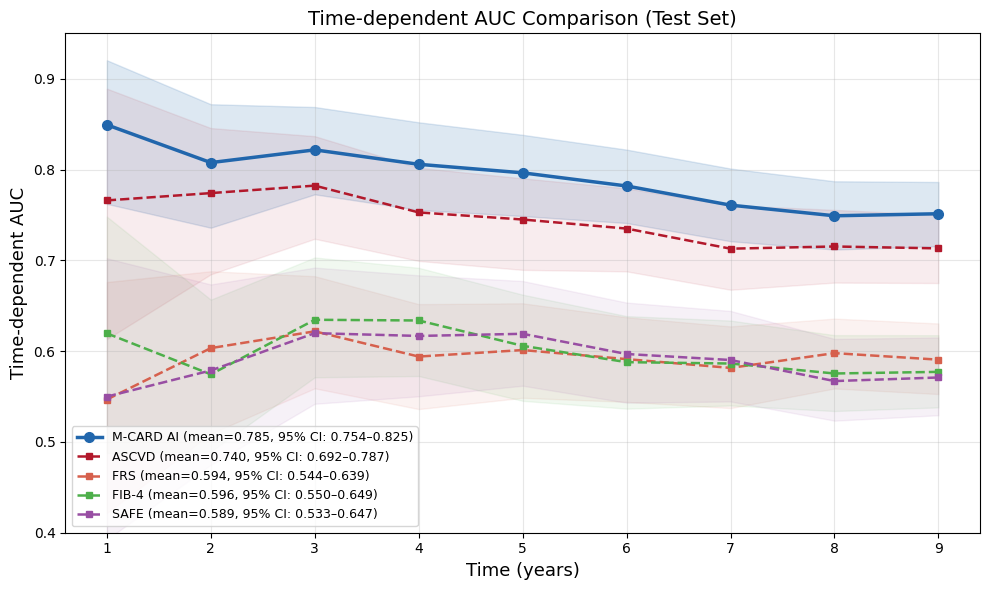

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sksurv.metrics import cumulative_dynamic_auc

# =============================================
# 1. TD-AUC with Bootstrap 95% CI
# =============================================
def compute_td_auc(time_train, event_train, time_test, event_test, 
                   pred_test, times=None):
    if times is None:
        times = np.arange(1, 11)
    
    max_train_time = time_train.max()
    time_test_capped = np.minimum(time_test, max_train_time - 0.01)
    
    y_train_surv = np.array(
        [(bool(e), t) for e, t in zip(event_train, time_train)],
        dtype=[('event', bool), ('time', float)]
    )
    y_test_surv = np.array(
        [(bool(e), t) for e, t in zip(event_test, time_test_capped)],
        dtype=[('event', bool), ('time', float)]
    )
    
    max_time = min(time_test_capped.max(), max_train_time)
    times = times[times < max_time]
    
    auc_values, mean_auc = cumulative_dynamic_auc(
        y_train_surv, y_test_surv, pred_test, times
    )
    
    return times, auc_values, mean_auc


def compute_td_auc_with_ci(time_train, event_train, time_test, event_test,
                           pred_test, times=None, n_boot=1000, seed=42):
    """Compute TD-AUC with bootstrap 95% CI."""
    np.random.seed(seed)
    
    if times is None:
        times = np.arange(1, 10)
    
    # Point estimate
    times_out, auc_point, mean_auc = compute_td_auc(
        time_train, event_train, time_test, event_test, pred_test, times
    )
    
    # Bootstrap: resample test set (train stays fixed for IPCW weights)
    n_test = len(time_test)
    boot_aucs = []
    
    for i in range(n_boot):
        idx = np.random.randint(0, n_test, size=n_test)
        try:
            _, auc_b, _ = compute_td_auc(
                time_train, event_train,
                time_test[idx], event_test[idx], pred_test[idx],
                times
            )
            boot_aucs.append(auc_b)
        except:
            continue
    
    boot_aucs = np.array(boot_aucs)  # shape: (n_successful_boots, n_timepoints)
    
    ci_lower = np.percentile(boot_aucs, 2.5, axis=0)
    ci_upper = np.percentile(boot_aucs, 97.5, axis=0)
    
    # Bootstrap CI for mean TD-AUC
    boot_means = np.mean(boot_aucs, axis=1)
    mean_ci_lower = np.percentile(boot_means, 2.5)
    mean_ci_upper = np.percentile(boot_means, 97.5)
    
    return {
        'times': times_out,
        'auc': auc_point,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'mean_auc': mean_auc,
        'mean_ci_lower': mean_ci_lower,
        'mean_ci_upper': mean_ci_upper
    }


# =============================================
# 2. Comparator scores
# =============================================
comparators = {
    'ASCVD': 'ASCVD_Risk',
    'FRS': 'FRS',
    'FIB-4': 'FIB4',
    'SAFE': 'SAFE'
}
comp_ext = {}
for name, col in comparators.items():
    comp_ext[name] = external_data[col].values

# =============================================
# 3. Plot with CI bands
# =============================================
times = np.arange(1, 10)

colors = {
    'M-CARD AI': '#2166AC',
    'ASCVD': '#B2182B',
    'FRS': '#D6604D',
    'FIB-4': '#4DAF4A',
    'SAFE': '#984EA3'
}

plt.figure(figsize=(10, 6))

# --- M-CARD AI ---
pred_ext = calibrated_model.predict_proba(X_external)[:, 1]
r = compute_td_auc_with_ci(
    time_train, event_train, time_ext, event_ext, pred_ext, times, n_boot=1000
)
plt.plot(r['times'], r['auc'], 'o-', color=colors['M-CARD AI'], linewidth=2.5,
         label=f'M-CARD AI (mean={r["mean_auc"]:.3f}, 95% CI: {r["mean_ci_lower"]:.3f}–{r["mean_ci_upper"]:.3f})',
         markersize=7, zorder=5)
plt.fill_between(r['times'], r['ci_lower'], r['ci_upper'],
                 color=colors['M-CARD AI'], alpha=0.15, zorder=1)

print(f"M-CARD AI: mean TD-AUC = {r['mean_auc']:.4f} ({r['mean_ci_lower']:.4f}–{r['mean_ci_upper']:.4f})")
for t, a, lo, hi in zip(r['times'], r['auc'], r['ci_lower'], r['ci_upper']):
    print(f"  {t:.0f}yr: {a:.4f} ({lo:.4f}–{hi:.4f})")

# --- Comparators ---
for name, scores in comp_ext.items():
    r_c = compute_td_auc_with_ci(
        time_train, event_train, time_ext, event_ext, scores, times, n_boot=1000
    )
    plt.plot(r_c['times'], r_c['auc'], 's--', color=colors[name], linewidth=1.8,
             label=f'{name} (mean={r_c["mean_auc"]:.3f}, 95% CI: {r_c["mean_ci_lower"]:.3f}–{r_c["mean_ci_upper"]:.3f})',
             markersize=5, zorder=4)
    plt.fill_between(r_c['times'], r_c['ci_lower'], r_c['ci_upper'],
                     color=colors[name], alpha=0.08, zorder=1)
    
    print(f"\n{name}: mean TD-AUC = {r_c['mean_auc']:.4f} ({r_c['mean_ci_lower']:.4f}–{r_c['mean_ci_upper']:.4f})")
    for t, a, lo, hi in zip(r_c['times'], r_c['auc'], r_c['ci_lower'], r_c['ci_upper']):
        print(f"  {t:.0f}yr: {a:.4f} ({lo:.4f}–{hi:.4f})")

plt.xlabel('Time (years)', fontsize=13)
plt.ylabel('Time-dependent AUC', fontsize=13)
plt.title('Time-dependent AUC Comparison (Test Set)', fontsize=14)
plt.legend(fontsize=9, loc='lower left')
plt.grid(True, alpha=0.3)
plt.ylim([0.40, 0.95])
plt.xticks(times)
plt.tight_layout()
plt.savefig('time_dependent_auc_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

In [95]:
# =============================================
# C-index: M-CARD AI + Comparators (all datasets)
# =============================================

# Comparator 점수 추출 (train, val, ext)
comp_scores = {}
for name, col in comparators.items():
    comp_scores[name] = {
        'Train': train_data.loc[train_idx, col].values,
        'Validation': train_data.loc[val_idx, col].values,
        'Test': external_data[col].values
    }

# M-CARD AI
pred_train = calibrated_model.predict_proba(X_train)[:, 1]
pred_val = calibrated_model.predict_proba(X_val)[:, 1]
pred_ext = calibrated_model.predict_proba(X_external)[:, 1]

print("=" * 70)
print("C-index Comparison (with 95% CI)")
print("=" * 70)

for dataset_name, t, e, p in [
    ('Train', time_train, event_train, pred_train),
    ('Validation', time_val, event_val, pred_val),
    ('Test', time_ext, event_ext, pred_ext),
]:
    print(f"\n--- {dataset_name} ---")
    
    # M-CARD AI
    r = cindex_with_ci(t, e, p)
    print(f"  M-CARD AI:  {r['c_index']:.4f} ({r['ci_lower']:.4f}–{r['ci_upper']:.4f})")
    
    # Comparators
    for comp_name in ['ASCVD', 'FRS', 'FIB-4', 'SAFE']:
        comp_pred = comp_scores[comp_name][dataset_name]
        rc = cindex_with_ci(t, e, comp_pred)
        print(f"  {comp_name:10s}:  {rc['c_index']:.4f} ({rc['ci_lower']:.4f}–{rc['ci_upper']:.4f})")

print("\n" + "=" * 70)

C-index Comparison (with 95% CI)

--- Train ---
  M-CARD AI:  0.7966 (0.7869–0.8069)
  ASCVD     :  0.6779 (0.6661–0.6895)
  FRS       :  0.5782 (0.5673–0.5906)
  FIB-4     :  0.5883 (0.5756–0.6013)
  SAFE      :  0.5430 (0.5298–0.5565)

--- Validation ---
  M-CARD AI:  0.7041 (0.6805–0.7256)
  ASCVD     :  0.6741 (0.6511–0.6967)
  FRS       :  0.5757 (0.5526–0.6001)
  FIB-4     :  0.5856 (0.5596–0.6104)
  SAFE      :  0.5609 (0.5360–0.5884)

--- Test ---
  M-CARD AI:  0.7519 (0.7222–0.7813)
  ASCVD     :  0.7133 (0.6799–0.7465)
  FRS       :  0.5898 (0.5552–0.6254)
  FIB-4     :  0.5817 (0.5463–0.6184)
  SAFE      :  0.5707 (0.5337–0.6112)



In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

def plot_combined_threshold_metrics(y_true, data, scores, pred_proba, name='unnamed'):
    plt.figure(figsize=(14, 6))
    
    # ROC Curve
    plt.subplot(1, 2, 1)
    plt.rcParams.update({
        "font.size": 12,            # 기본 폰트 크기
        "axes.labelsize": 14,       # x/y축 라벨 폰트
        "axes.titlesize": 16,       # 제목 폰트
        "legend.fontsize": 12,      # 범례 폰트
        "lines.linewidth": 2.5,     # 선 두께
        "axes.linewidth": 1.2,      # 축 테두리 두께
    })
    
    # Plot for ML model
    fpr_ml, tpr_ml, _ = roc_curve(y_true, pred_proba)
    auroc_ml = roc_auc_score(y_true, pred_proba)
    plt.plot(fpr_ml, tpr_ml, color='black', lw=2, label=f'ML Model (AUROC: {auroc_ml:.2f})')
    
    # Plot for traditional scores
    for score, color in zip(scores, sns.color_palette("husl", len(scores))):
        fpr, tpr, _ = roc_curve(y_true, data[score])
        score_auroc = roc_auc_score(y_true, data[score])
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{score} (AUROC: {score_auroc:.2f})')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for ML Model and Traditional Scores')
    plt.legend(loc='lower right')
    
    
    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    precision_ml, recall_ml, _ = precision_recall_curve(y_true, pred_proba)
    auprc_ml = average_precision_score(y_true, pred_proba)
    plt.plot(recall_ml, precision_ml, color='black', lw=2, label=f'ML Model (AUPRC: {auprc_ml:.2f})')
    
    for score, color in zip(scores, sns.color_palette("husl", len(scores))):
        precision, recall, _ = precision_recall_curve(y_true, data[score])
        auprc = average_precision_score(y_true, data[score])
        plt.plot(recall, precision, color=color, lw=2, label=f'{score} (AUPRC: {auprc:.2f})')
        
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves for ML Model and Traditional Scores')
    plt.legend(loc='upper right')
    plt.savefig(f"{name}.png", dpi=1200, bbox_inches='tight')    
    sns.despine()  # Removes the top and right spines from plot
    plt.tight_layout()
    plt.show()
    

In [76]:
# *** Prediction results in Training***
y_train_pred_proba = calibrated_model.predict_proba(X_train)[:, 1]

# find youden idx
fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_proba)
# Youden Index 계산: Sensitivity + Specificity - 1
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold using Youden Index:", optimal_threshold)

y_train_pred = (y_train_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_train = classification_report(y_train, y_train_pred, target_names=['Class 0', 'Class 1'])
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
auprc_train = average_precision_score(y_train, y_train_pred_proba)


# *** Prediction results in Internal validation***
y_val_pred_proba = calibrated_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_val = classification_report(y_val, y_val_pred, target_names=['Class 0', 'Class 1'])
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
auprc_val = average_precision_score(y_val, y_val_pred_proba)

# *** Prediction results in External validation***
y_external_pred_proba = calibrated_model.predict_proba(X_external)[:, 1]
y_external_pred = (y_external_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_external = classification_report(y_external, y_external_pred, target_names=['Class 0', 'Class 1'])
roc_auc_external = roc_auc_score(y_external, y_external_pred_proba)
auprc_external = average_precision_score(y_external, y_external_pred_proba)


# # *** Prediction results in External validation***
# y_koges_pred = model.predict(X_koges)
# y_koges_pred_proba = model.predict_proba(X_koges)[:, 1]

# # Calculating metrics for the external validation
# classification_report_koges = classification_report(y_koges, y_koges_pred, target_names=['Class 0', 'Class 1'])
# roc_auc_koges = roc_auc_score(y_koges, y_koges_pred_proba)
# auprc_koges = average_precision_score(y_koges, y_koges_pred_proba)

Optimal Threshold using Youden Index: 0.06474869810044766


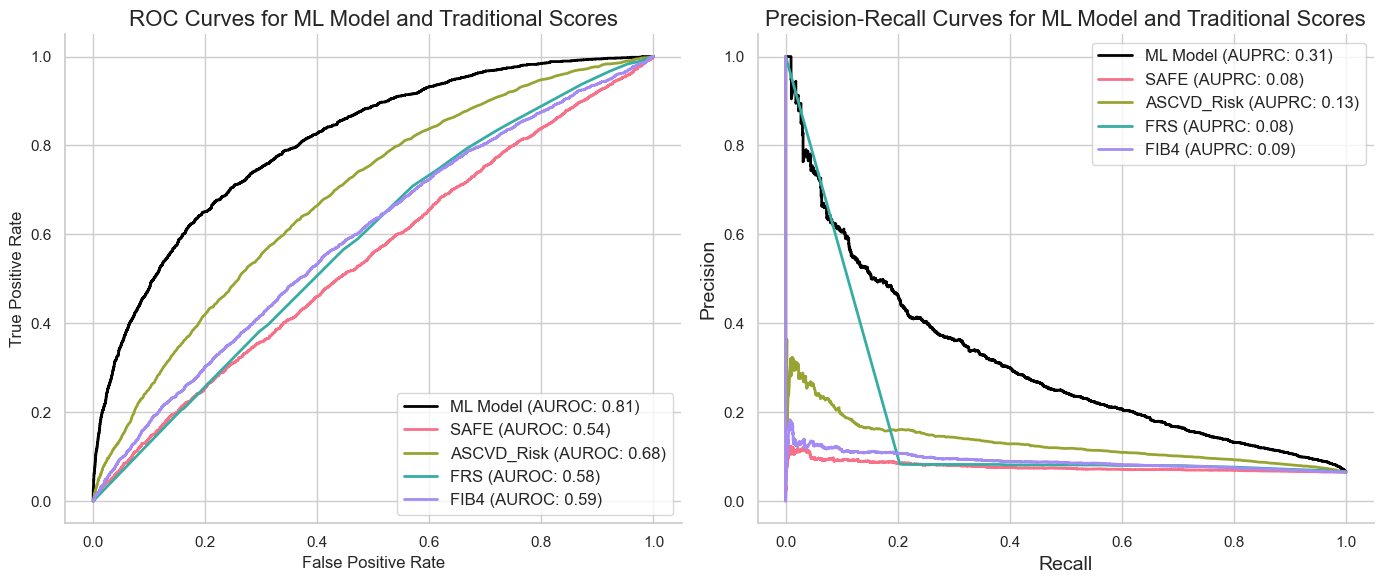

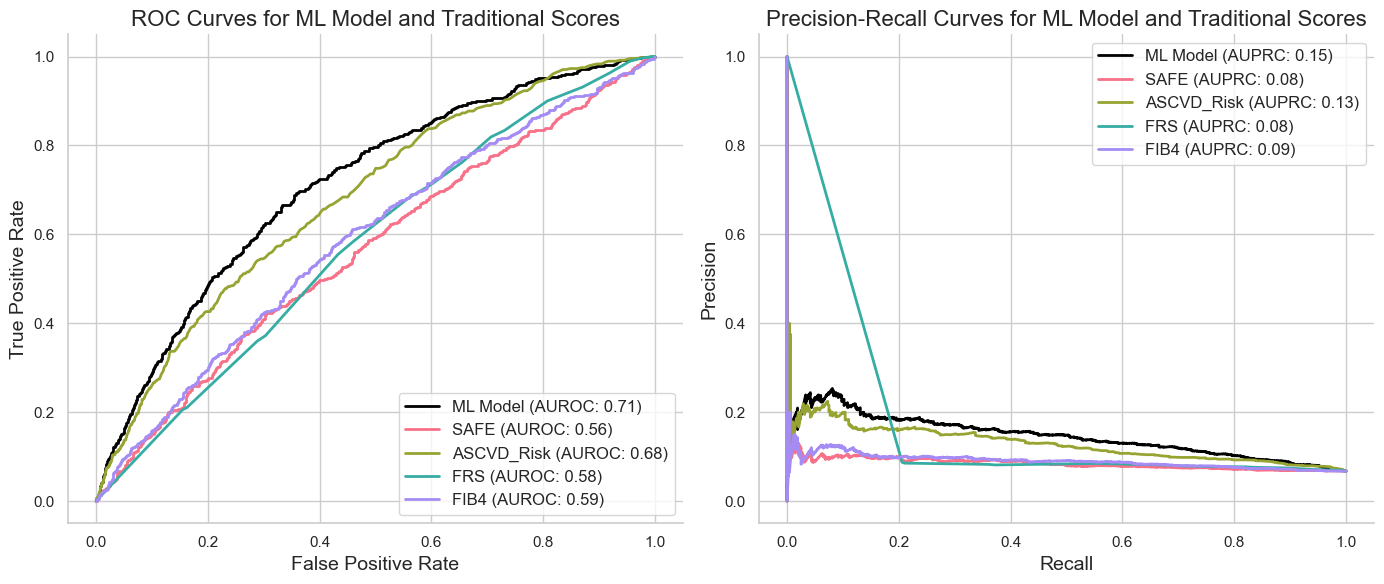

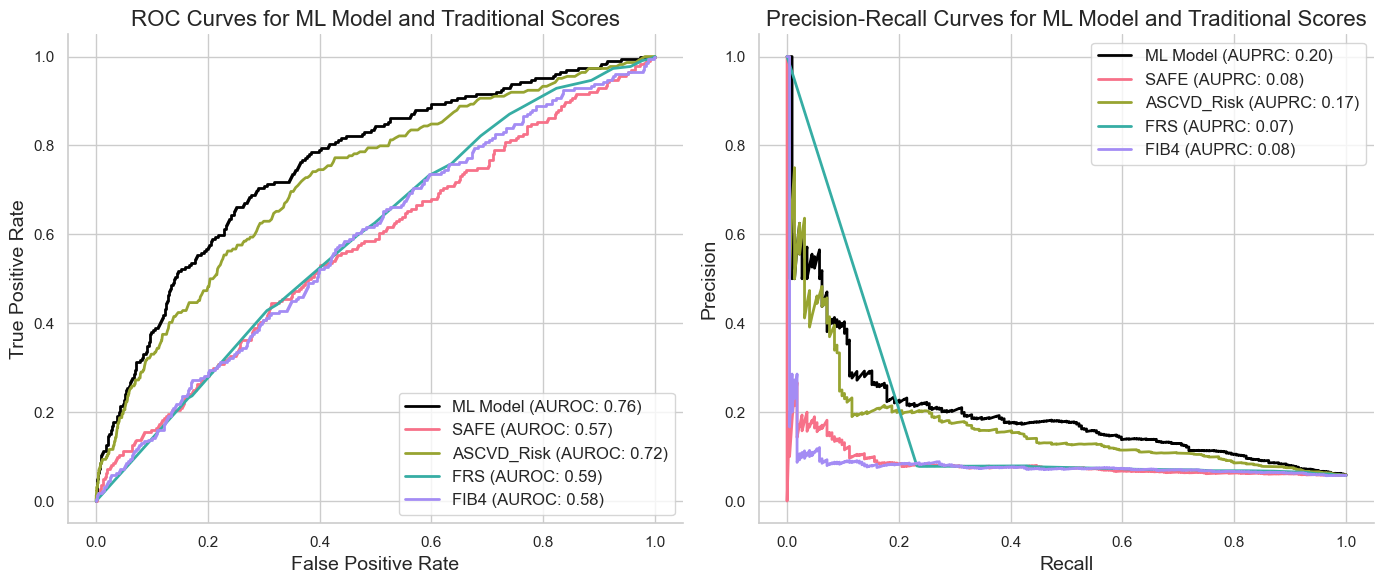

In [77]:
# Set Seaborn style
sns.set(style="whitegrid")
# Combined plot for all traditional scores with Seaborn styling
plot_combined_threshold_metrics(y_train, redefined_ukb_data2.query("region == 'England'").reset_index().loc[train_idx], ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_train_pred_proba, 'train')
plot_combined_threshold_metrics(y_val, redefined_ukb_data2.query("region == 'England'").reset_index().loc[val_idx], ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_val_pred_proba, 'internal')
plot_combined_threshold_metrics(y_external, redefined_ukb_data2.query("region != 'England'").reset_index(), ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_external_pred_proba, 'test')

In [79]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'AUROC': roc_auc_score(y_true, y_proba),
        'AUPRC': average_precision_score(y_true, y_proba),
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Precision': precision_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

    return pd.DataFrame([metrics])

In [80]:
metrics_df = evaluate_model(y_train, y_train_pred, y_train_pred_proba)
metrics_df

,Accuracy,AUROC,AUPRC,Sensitivity (Recall),Specificity,Precision,F1 Score
0,0.745253,0.807918,0.305589,0.711683,0.747592,0.164194,0.266827


In [81]:
metrics_df = evaluate_model(y_val, y_val_pred, y_val_pred_proba)
metrics_df

,Accuracy,AUROC,AUPRC,Sensitivity (Recall),Specificity,Precision,F1 Score
0,0.729824,0.712046,0.146045,0.555094,0.742404,0.134306,0.216282


In [82]:
metrics_df = evaluate_model(y_external, y_external_pred, y_external_pred_proba)
metrics_df

,Accuracy,AUROC,AUPRC,Sensitivity (Recall),Specificity,Precision,F1 Score
0,0.753929,0.758155,0.198256,0.629464,0.761553,0.139191,0.227971


# KM Curve

In [159]:
km_test_train = redefined_ukb_data2.query("region=='England'").reset_index().loc[train_idx]

In [160]:
km_test_val = redefined_ukb_data2.query("region=='England'").reset_index().loc[val_idx]

In [161]:
km_test_external = redefined_ukb_data2.query("region!='England'").reset_index()

In [163]:
# outcome 관련 컬럼들만 선택 (예: 'disease1_time', 'disease2_time', 'disease3_time' 등의 컬럼)
outcome_columns = ['cardiac_death', 'cardiac_dx', 'MI_bi', 'STROKE_bi', 'STEMI_bi', 'NSTEMI_bi','ISCHAEMIC_bi','INTRACEREBRAL_HEMO_bi', 'SUBARACHNOID_HEMO_bi']

# 각 행에서 NaN이 아닌 값 중 최소값을 찾음
km_test_train['min_outcome_time'] = km_test_train[outcome_columns].min(axis=1)
km_test_val['min_outcome_time'] = km_test_val[outcome_columns].min(axis=1)
km_test_external['min_outcome_time'] = km_test_external[outcome_columns].min(axis=1)

In [164]:
## 질병발생하지않은 사람 관측기간 최대로설정 3650
km_test_train.loc[km_test_train['redefined_outcome'] == 0, 'min_outcome_time'] = 3650
km_test_val.loc[km_test_val['redefined_outcome'] == 0, 'min_outcome_time'] = 3650
km_test_external.loc[km_test_external['redefined_outcome'] == 0, 'min_outcome_time'] = 3650

In [165]:
km_test_train['score'] = y_train_pred_proba
km_test_val['score'] = y_val_pred_proba
km_test_external['score'] = y_external_pred_proba

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

def prepare_data(df):
    df['risk_group'] = pd.qcut(df['ai_score'], q=3, labels=['Low', 'Moderate', 'High'])
    return df

def perform_km_analysis(data):
    kmf = KaplanMeierFitter()
    
    results = {}
    for group in ['Low', 'Moderate', 'High']:
        mask = data['risk_group'] == group
        kmf.fit(
            durations=data.loc[mask, 'follow_up_time'],
            event_observed=data.loc[mask, 'cvd_event'],
            label=f'{group} Risk'
        )
        # Series를 float로 변환
        results[group] = float(1 - kmf.survival_function_at_times(120))
    
    return results

In [167]:
def plot_km_curves(data, name='unnamed'):
    # 그래프 초기 설정
    plt.figure(figsize=(10, 8))
    plt.subplots_adjust(hspace=0.4)
    
    # 색상 설정
    colors = {'Low': 'green', 'Moderate': 'blue', 'High': 'red'}
    at_risk_groups = {}
    kmf = KaplanMeierFitter()
    
    # 결과를 저장할 딕셔너리
    results = {}
    
    # 상단 그래프 (메인 KM curve)
    plt.subplot(2, 1, 1)
    for group in ['Low', 'Moderate', 'High']:
        # 그룹별 데이터 준비
        mask = data['risk_group'] == group
        group_data = data[mask]
        
        # 그룹 사이즈와 이벤트 수 계산
        n_patients = sum(mask)
        n_events = sum(group_data['cvd_event'])
        
        # KM fit
        kmf.fit(
            durations=group_data['follow_up_time'],
            event_observed=group_data['cvd_event'],
            label=f'{group} Risk'  # Keep simple label for now
        )
        
        # 발생률 계산
        sf = kmf.survival_function_
        incidence = 1 - sf
        timeline_years = sf.index / 365
        
        # 10년 시점 (또는 가장 가까운 시간점)의 발생률과 CI 계산
        target_year = 10
        closest_time_idx = abs(timeline_years - target_year).argmin()
        
        if closest_time_idx < len(timeline_years):
            cum_incidence = float(incidence.iloc[closest_time_idx].values[0])
            
            # CI 계산
            if kmf.confidence_interval_ is not None:
                ci_lower = 1 - float(kmf.confidence_interval_.iloc[closest_time_idx, 1])
                ci_upper = 1 - float(kmf.confidence_interval_.iloc[closest_time_idx, 0])
            else:
                ci_lower = ci_upper = None
                
            # 결과 저장
            results[group] = {
                'n_patients': n_patients,
                'n_events': n_events,
                'cum_incidence': cum_incidence,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper
            }
        
        # 그래프 그리기
        plt.plot(
            timeline_years,
            incidence.values,
            label=f'{group} Risk',
            color=colors[group]
        )
        
        # 신뢰구간
        if kmf.confidence_interval_ is not None:
            ci = 1 - kmf.confidence_interval_
            plt.fill_between(
                timeline_years,
                ci.iloc[:, 0],
                ci.iloc[:, 1],
                alpha=0.2,
                color=colors[group]
            )
        
        # Number at risk 계산
        at_risk_years = [0, 2, 4, 6, 8, 10]
        at_risk_counts = []
        for year in at_risk_years:
            count = sum(group_data['follow_up_time'] >= year * 365)
            at_risk_counts.append(count)
        at_risk_groups[group] = at_risk_counts
    
    # 상단 그래프 스타일링
    plt.xlabel('Follow-up Time (years)')
    plt.ylabel('Cumulative CVD Incidence (%)')
    plt.title('10-Year CVD Incidence by Risk Group')
    plt.grid(True)
    plt.ylim(0, plt.ylim()[1])
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Get the current legend handles and labels
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    
    # Create new labels with incidence and CI info
    new_labels = []
    for i, group in enumerate(['Low', 'Moderate', 'High']):
        if group in results:
            inc = results[group]['cum_incidence'] * 100
            ci_l = results[group]['ci_lower'] * 100
            ci_u = results[group]['ci_upper'] * 100
            new_label = f"{group} Risk: {inc:.1f}% (95% CI: {ci_l:.1f}–{ci_u:.1f}%)"
            new_labels.append(new_label)
    
    # Create legend with original handles but new detailed labels
    plt.legend(handles, new_labels)
    
    # 하단 테이블 (Number at risk)
    plt.subplot(2, 1, 2)
    plt.table(
        cellText=[at_risk_groups[group] for group in ['Low', 'Moderate', 'High']],
        rowLabels=['Low Risk', 'Moderate Risk', 'High Risk'],
        colLabels=['0', '2', '4', '6', '8', '10'],
        loc='center',
        cellLoc='center'
    )
    plt.axis('off')
    plt.title('Number at Risk')
    
    # 전체 이벤트 수와 발생률 계산
    total_patients = len(data)
    total_events = sum(data['cvd_event'])
    overall_event_rate = total_events / total_patients * 100
    
    # 중앙 추적 기간 계산 (날짜를 연도로 변환)
    median_followup = np.median(data['follow_up_time']) / 365
    
    # 추가 정보 리턴
    summary = {
        'total_patients': total_patients,
        'total_events': total_events,
        'event_rate': overall_event_rate,
        'median_followup': median_followup,
        'group_results': results
    }
    plt.savefig(f"{name}.png", dpi=1200, bbox_inches='tight')

    
    return plt, summary

# Train


Based on the model's output probability, patients were categorized into Low Risk (n = 9550), 
Moderate Risk (n = 9548), and High Risk (n = 9550) groups. 
Over a median follow-up period of 10.0 years, a total of 1866 events occurred, 
corresponding to an overall event rate of 6.5%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: 89 events, cumulative incidence 0.9% (95% CI: 0.8–1.1%)
* **Moderate Risk**: 372 events, cumulative incidence 3.9% (95% CI: 3.5–4.3%)
* **High Risk**: 1405 events, cumulative incidence 14.7% (95% CI: 14.0–15.4%)



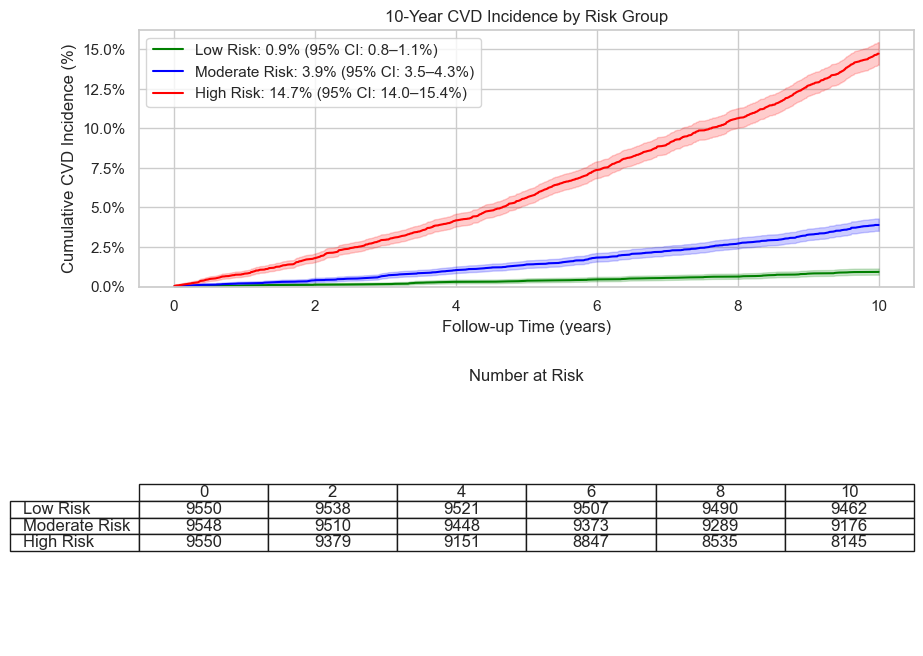

In [168]:
# Call the modified function
df = km_test_train[['score', 'min_outcome_time', 'redefined_outcome']]
df.columns = ['ai_score', 'follow_up_time', 'cvd_event']
df = prepare_data(df)
plot, summary = plot_km_curves(df, 'train_km')

# Get values for your text
total_events = summary['total_events']
event_rate = summary['event_rate']
median_followup = summary['median_followup']

# Get group information
low_risk = summary['group_results']['Low']
moderate_risk = summary['group_results']['Moderate']
high_risk = summary['group_results']['High']

formatted_text = f"""
Based on the model's output probability, patients were categorized into Low Risk (n = {low_risk['n_patients']}), 
Moderate Risk (n = {moderate_risk['n_patients']}), and High Risk (n = {high_risk['n_patients']}) groups. 
Over a median follow-up period of {median_followup:.1f} years, a total of {total_events} events occurred, 
corresponding to an overall event rate of {event_rate:.1f}%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: {low_risk['n_events']} events, cumulative incidence {low_risk['cum_incidence']*100:.1f}% (95% CI: {low_risk['ci_lower']*100:.1f}–{low_risk['ci_upper']*100:.1f}%)
* **Moderate Risk**: {moderate_risk['n_events']} events, cumulative incidence {moderate_risk['cum_incidence']*100:.1f}% (95% CI: {moderate_risk['ci_lower']*100:.1f}–{moderate_risk['ci_upper']*100:.1f}%)
* **High Risk**: {high_risk['n_events']} events, cumulative incidence {high_risk['cum_incidence']*100:.1f}% (95% CI: {high_risk['ci_lower']*100:.1f}–{high_risk['ci_upper']*100:.1f}%)
"""

print(formatted_text)

# Internal Validation


Based on the model's output probability, patients were categorized into Low Risk (n = 2388), 
Moderate Risk (n = 2386), and High Risk (n = 2388) groups. 
Over a median follow-up period of 10.0 years, a total of 481 events occurred, 
corresponding to an overall event rate of 6.7%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: 53 events, cumulative incidence 2.2% (95% CI: 1.7–2.9%)
* **Moderate Risk**: 124 events, cumulative incidence 5.2% (95% CI: 4.4–6.2%)
* **High Risk**: 304 events, cumulative incidence 12.7% (95% CI: 11.5–14.1%)



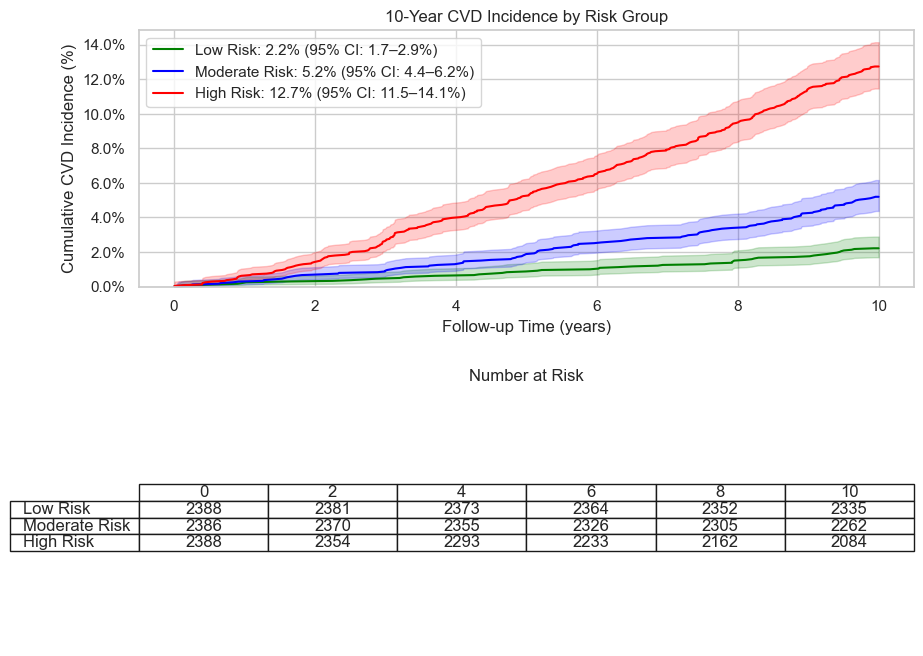

In [169]:
# 실행
df = km_test_val[['score', 'min_outcome_time', 'redefined_outcome']]
df.columns = ['ai_score', 'follow_up_time', 'cvd_event']
df = prepare_data(df)
plot, summary = plot_km_curves(df, 'internal_km')

# Get values for your text
total_events = summary['total_events']
event_rate = summary['event_rate']
median_followup = summary['median_followup']

# Get group information
low_risk = summary['group_results']['Low']
moderate_risk = summary['group_results']['Moderate']
high_risk = summary['group_results']['High']

formatted_text = f"""
Based on the model's output probability, patients were categorized into Low Risk (n = {low_risk['n_patients']}), 
Moderate Risk (n = {moderate_risk['n_patients']}), and High Risk (n = {high_risk['n_patients']}) groups. 
Over a median follow-up period of {median_followup:.1f} years, a total of {total_events} events occurred, 
corresponding to an overall event rate of {event_rate:.1f}%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: {low_risk['n_events']} events, cumulative incidence {low_risk['cum_incidence']*100:.1f}% (95% CI: {low_risk['ci_lower']*100:.1f}–{low_risk['ci_upper']*100:.1f}%)
* **Moderate Risk**: {moderate_risk['n_events']} events, cumulative incidence {moderate_risk['cum_incidence']*100:.1f}% (95% CI: {moderate_risk['ci_lower']*100:.1f}–{moderate_risk['ci_upper']*100:.1f}%)
* **High Risk**: {high_risk['n_events']} events, cumulative incidence {high_risk['cum_incidence']*100:.1f}% (95% CI: {high_risk['ci_lower']*100:.1f}–{high_risk['ci_upper']*100:.1f}%)
"""

print(formatted_text)

# Test


Based on the model's output probability, patients were categorized into Low Risk (n = 1294), 
Moderate Risk (n = 1293), and High Risk (n = 1294) groups. 
Over a median follow-up period of 10.0 years, a total of 224 events occurred, 
corresponding to an overall event rate of 5.8%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: 23 events, cumulative incidence 1.8% (95% CI: 1.2–2.7%)
* **Moderate Risk**: 42 events, cumulative incidence 3.2% (95% CI: 2.4–4.4%)
* **High Risk**: 159 events, cumulative incidence 12.3% (95% CI: 10.6–14.2%)



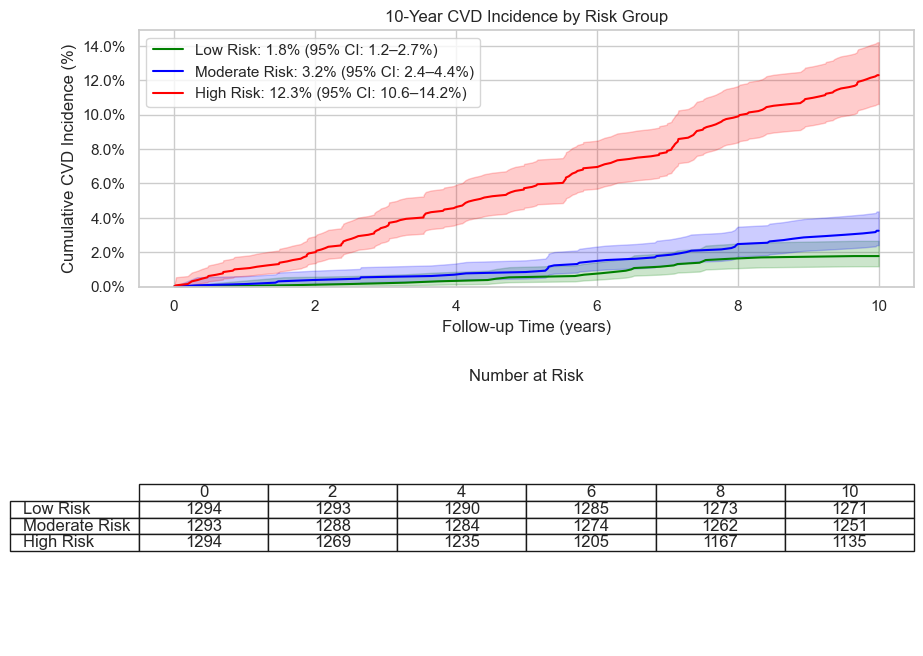

In [170]:
# 실행
df = km_test_external[['score', 'min_outcome_time', 'redefined_outcome']]
df.columns = ['ai_score', 'follow_up_time', 'cvd_event']
df = prepare_data(df)
plot, summary = plot_km_curves(df, 'test_km')

# Get values for your text
total_events = summary['total_events']
event_rate = summary['event_rate']
median_followup = summary['median_followup']

# Get group information
low_risk = summary['group_results']['Low']
moderate_risk = summary['group_results']['Moderate']
high_risk = summary['group_results']['High']

formatted_text = f"""
Based on the model's output probability, patients were categorized into Low Risk (n = {low_risk['n_patients']}), 
Moderate Risk (n = {moderate_risk['n_patients']}), and High Risk (n = {high_risk['n_patients']}) groups. 
Over a median follow-up period of {median_followup:.1f} years, a total of {total_events} events occurred, 
corresponding to an overall event rate of {event_rate:.1f}%.

Table 2 displays the cumulative risk (or incidence) of the event in each group:
* **Low Risk**: {low_risk['n_events']} events, cumulative incidence {low_risk['cum_incidence']*100:.1f}% (95% CI: {low_risk['ci_lower']*100:.1f}–{low_risk['ci_upper']*100:.1f}%)
* **Moderate Risk**: {moderate_risk['n_events']} events, cumulative incidence {moderate_risk['cum_incidence']*100:.1f}% (95% CI: {moderate_risk['ci_lower']*100:.1f}–{moderate_risk['ci_upper']*100:.1f}%)
* **High Risk**: {high_risk['n_events']} events, cumulative incidence {high_risk['cum_incidence']*100:.1f}% (95% CI: {high_risk['ci_lower']*100:.1f}–{high_risk['ci_upper']*100:.1f}%)
"""

print(formatted_text)

# SHAP, PDP

PermutationExplainer explainer: 28692it [11:50, 39.73it/s]                      


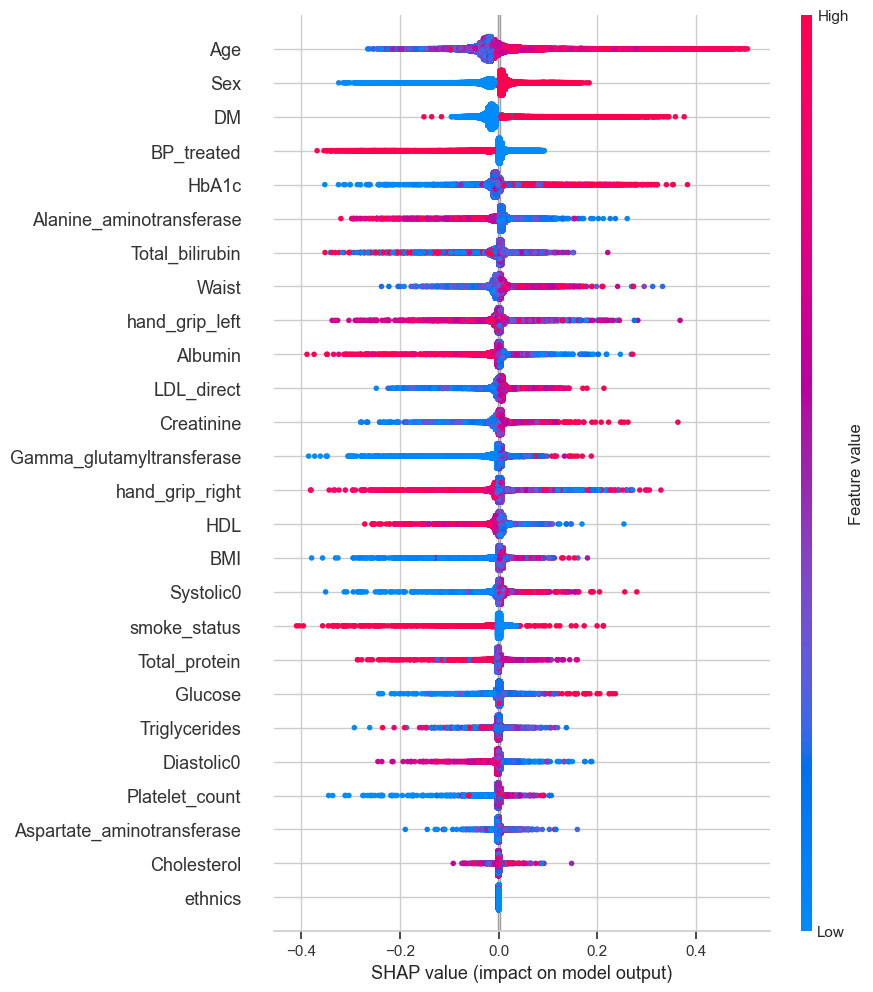

In [119]:
import shap
import matplotlib.pyplot as plt

# 1. Permutation Explainer 설정 
# model.predict를 넣으면 모델 내부를 보지 않고 입력/출력만 확인합니다.
explainer = shap.Explainer(model.predict, X_train)

# 2. SHAP 값 계산 (데이터가 많으면 시간이 걸릴 수 있으니 100개 정도로 샘플링 권장)
# 전체 데이터를 다 하려면 X_train을 그대로 넣으세요.
shap_values = explainer(X_train) 

# 3. 시각화 (모든 피처 출력)
# max_display에 피처의 총 개수를 넣어주면 생략 없이 다 나옵니다.
plt.figure(figsize=(10, 12)) # 피처가 많으면 세로 길이를 늘려주는 게 좋습니다.
shap.plots.beeswarm(shap_values, max_display=X_train.shape[1])

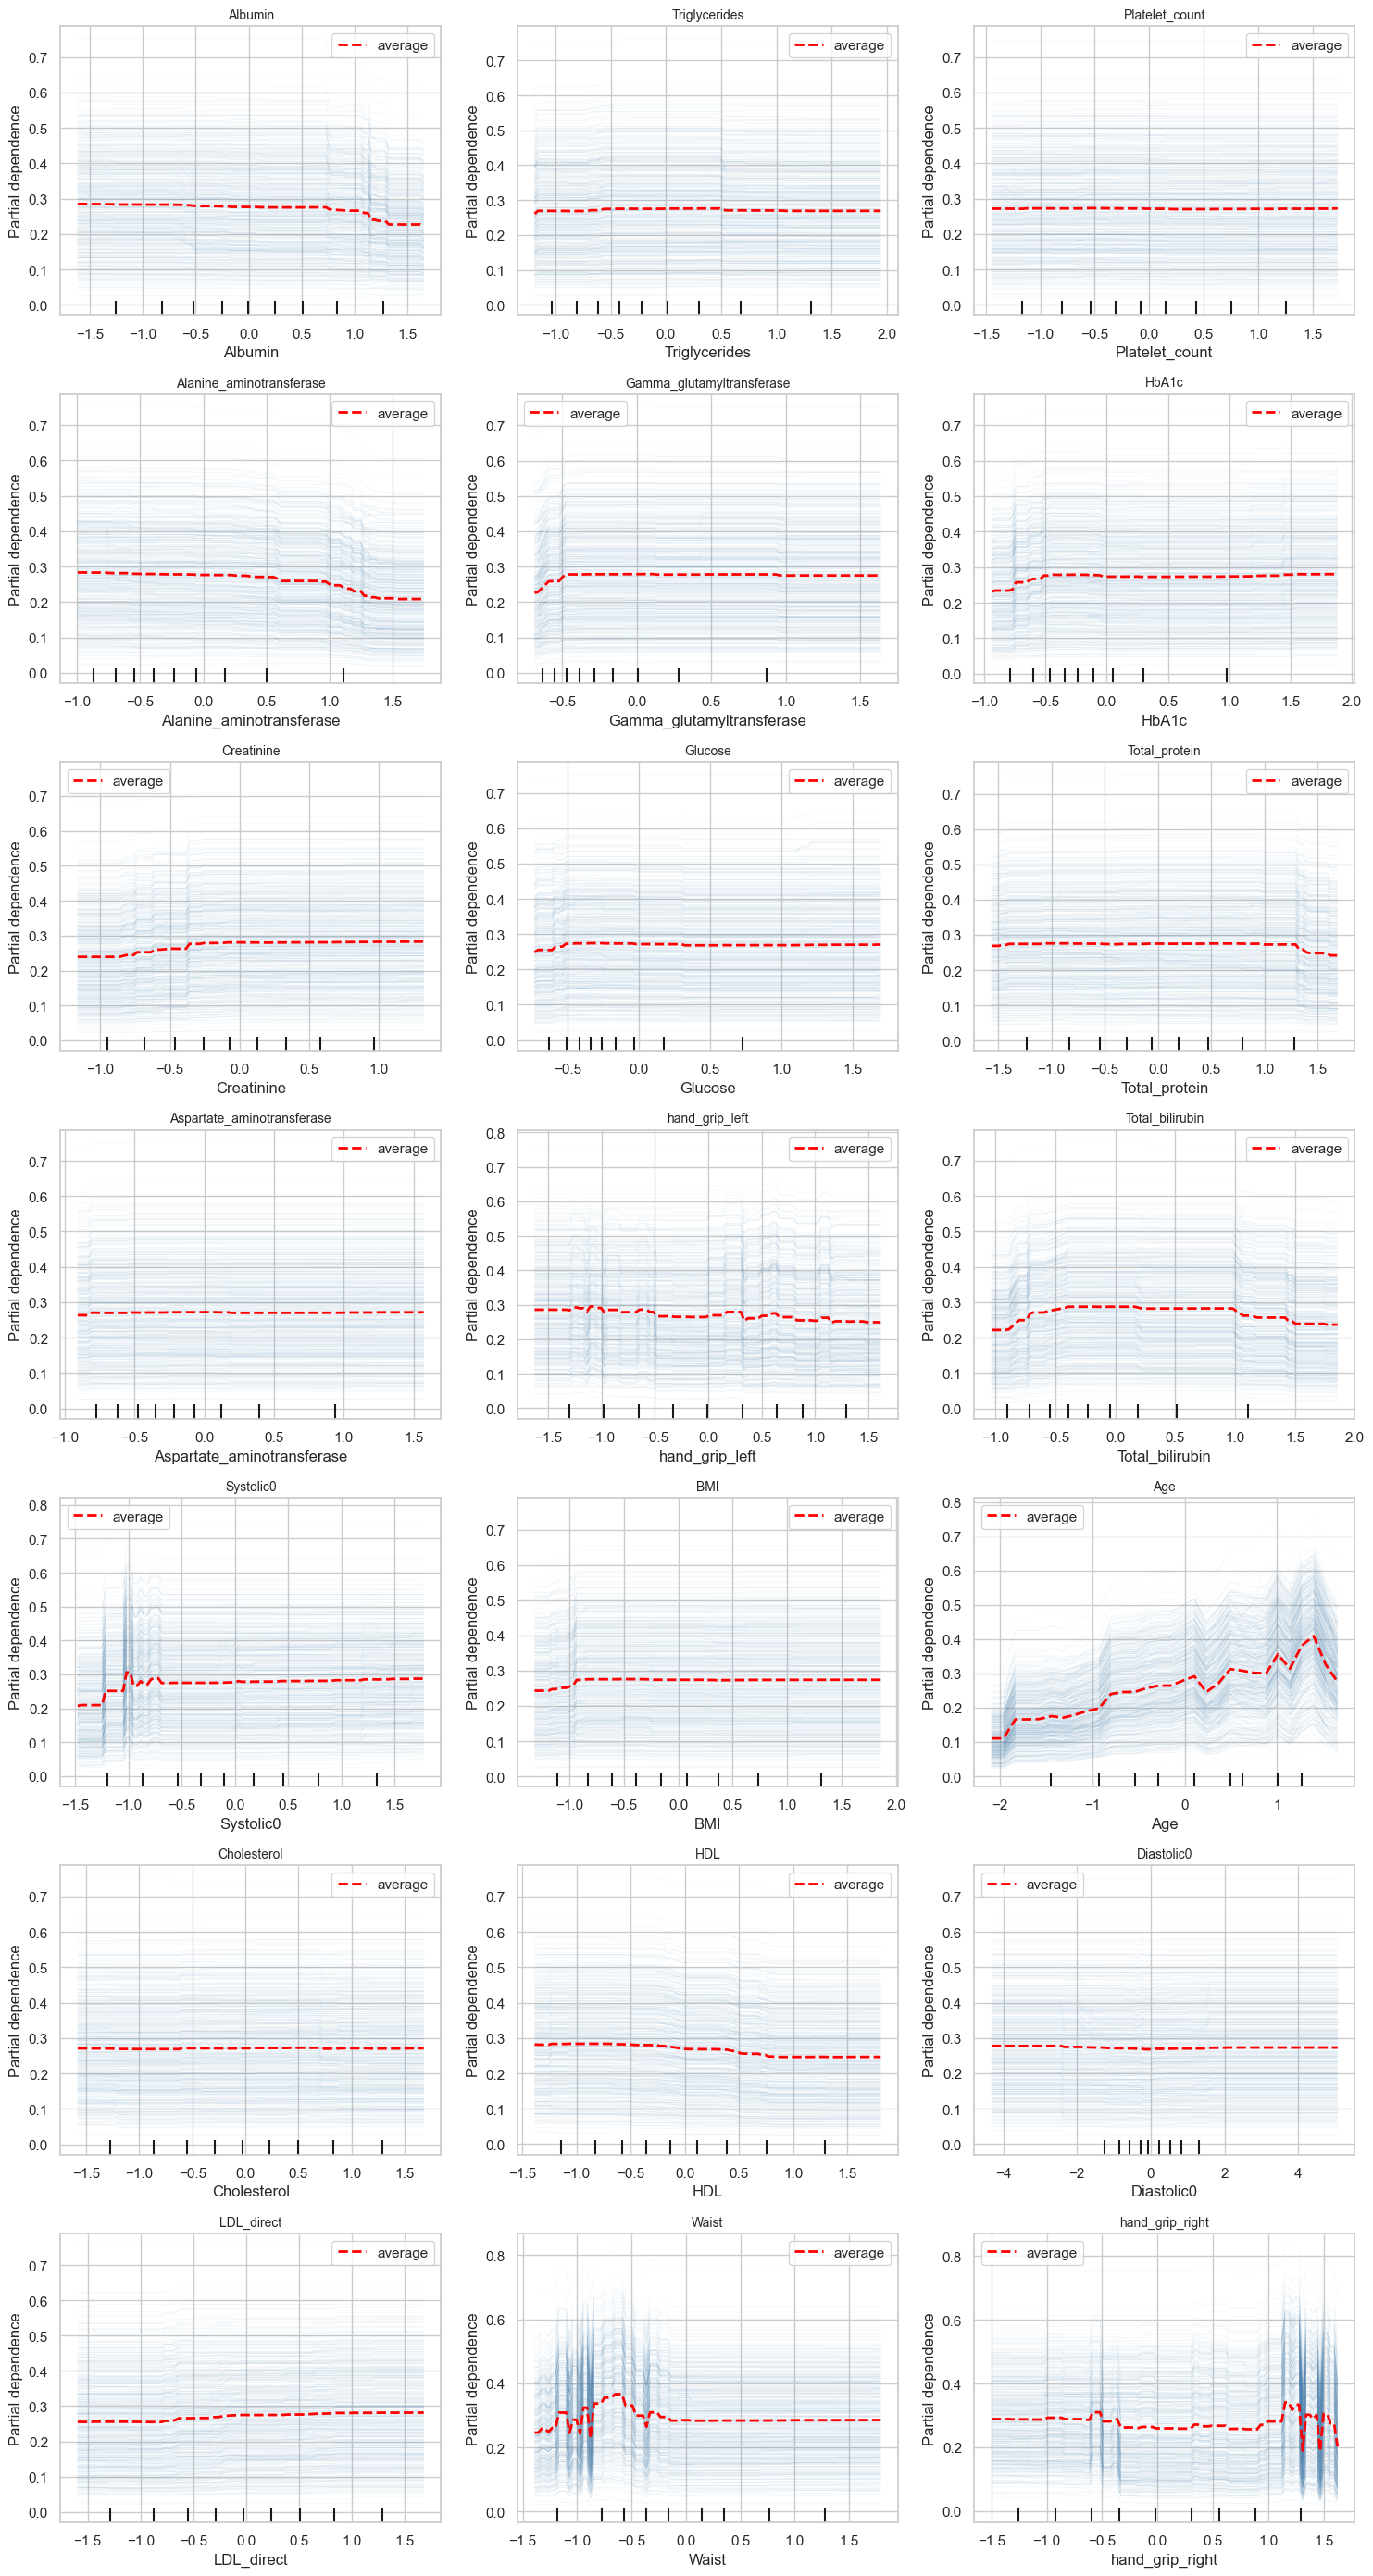

In [158]:
categorical_cols = ['Sex', 'smoke_status', 'DM', 'BP_treated', 'ethnics']

continuous_features = [f for f in X_train.columns if f not in categorical_cols]
n_features = len(continuous_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    feat_idx = list(X_train.columns).index(feat)
    try:
        PartialDependenceDisplay.from_estimator(
            model,
            X_train,
            features=[feat_idx],
            kind='both',
            subsample=500,
            ice_lines_kw={'color': 'steelblue', 'alpha': 0.05, 'linewidth': 0.5},
            pd_line_kw={'color': 'red', 'linewidth': 2},
            ax=axes[i],
            random_state=42
        )
        axes[i].set_title(feat, fontsize=10)
    except Exception as e:
        axes[i].set_title(f'{feat} (error)', fontsize=10)
        axes[i].text(0.5, 0.5, str(e)[:50], transform=axes[i].transAxes, ha='center')

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('pdp_ice_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# 

# DCA

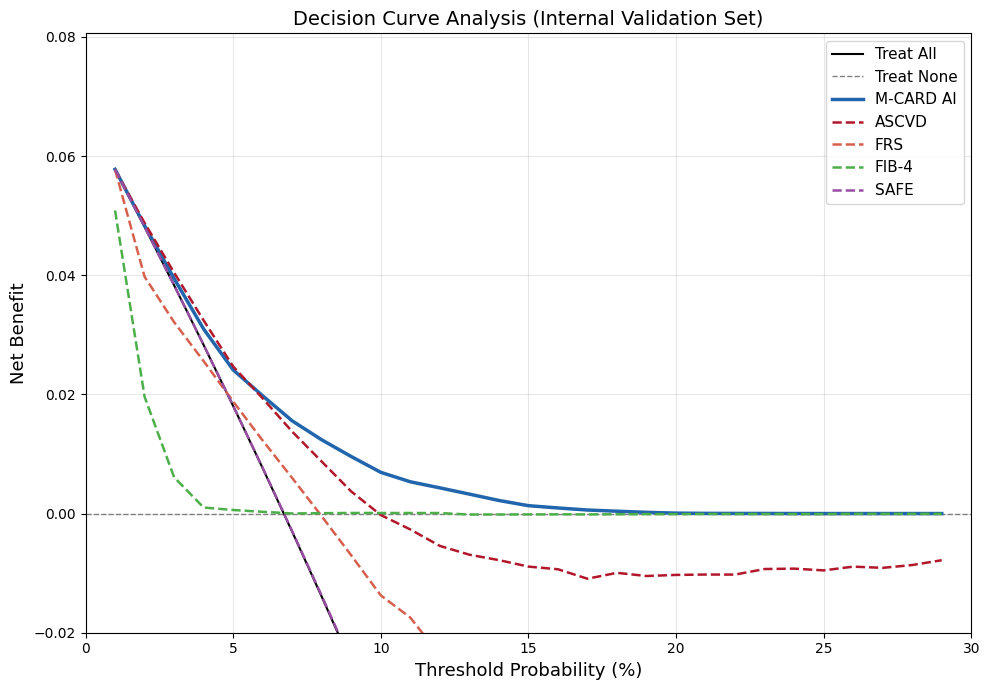

In [128]:
# =============================================
# DCA: Internal Validation Set (calibration 적절한 데이터)
# =============================================
pred_val_cal = calibrated_model.predict_proba(X_val)[:, 1]
prevalence_val = np.mean(y_val)

# Comparator 점수 (validation set)
ascvd_val = train_data.loc[val_idx, 'ASCVD_Risk'].values / 100
frs_val_prob = np.array([
    frs_points_to_risk(p, s) 
    for p, s in zip(train_data.loc[val_idx, 'FRS'].values, 
                     train_data.loc[val_idx, 'Sex'].values)
])
fib4_val = train_data.loc[val_idx, 'FIB4'].values
safe_val = train_data.loc[val_idx, 'SAFE'].values
fib4_val_norm = (fib4_val - fib4_val.min()) / (fib4_val.max() - fib4_val.min())
safe_val_norm = (safe_val - safe_val.min()) / (safe_val.max() - safe_val.min())

comp_val = {
    'ASCVD': ascvd_val,
    'FRS': frs_val_prob,
    'FIB-4': fib4_val_norm,
    'SAFE': safe_val_norm
}

thresholds = np.arange(0.01, 0.30, 0.01)  # 1-30%로 축소

plt.figure(figsize=(10, 7))

treat_all = prevalence_val - (1 - prevalence_val) * (thresholds / (1 - thresholds))
plt.plot(thresholds * 100, treat_all, 'k-', linewidth=1.5, label='Treat All')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, label='Treat None')

nb_mcard = compute_net_benefit(y_val.values, pred_val_cal, thresholds)
plt.plot(thresholds * 100, nb_mcard, linewidth=2.5,
         color='#2166AC', label='M-CARD AI')

for name, probs in comp_val.items():
    nb = compute_net_benefit(y_val.values, probs, thresholds)
    plt.plot(thresholds * 100, nb, linewidth=1.8, linestyle='--',
             color=colors_dca[name], label=name)

plt.xlabel('Threshold Probability (%)', fontsize=13)
plt.ylabel('Net Benefit', fontsize=13)
plt.title('Decision Curve Analysis (Internal Validation Set)', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.xlim([0, 30])
plt.ylim([-0.02, max(0.08, prevalence_val * 1.2)])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dca_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# 95% CI

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from scipy.interpolate import interp1d

def bootstrap_curves(y_true, pred_proba, curve_type='roc', n_bootstraps=100, random_state=138):
    """ 
    부트스트랩으로 ROC 또는 PR 커브를 구해 평균 및 CI를 반환.
    """
    rng = np.random.RandomState(random_state)
    base_axis = np.linspace(0, 1, 1000)
    boot_curves = []
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue
        if curve_type == 'roc':
            fpr, tpr, _ = roc_curve(y_true[indices], pred_proba[indices])
            interp_tpr = interp1d(fpr, tpr, kind='nearest', fill_value="extrapolate")(base_axis)
            boot_curves.append(interp_tpr)
        elif curve_type == 'pr':
            precision, recall, _ = precision_recall_curve(y_true[indices], pred_proba[indices])
            interp_precision = interp1d(recall, precision, kind='nearest', fill_value="extrapolate")(base_axis)
            boot_curves.append(interp_precision)
    
    boot_curves = np.array(boot_curves)
    lower = np.percentile(boot_curves, 2.5, axis=0)
    upper = np.percentile(boot_curves, 97.5, axis=0)
    mean_curve = np.mean(boot_curves, axis=0)
    
    return base_axis, mean_curve, lower, upper

def bootstrap_metric_ci(y_true, pred_proba, metric_func, n_bootstraps=1000, random_state=138):
    """
    부트스트랩으로 metric(AUROC 또는 AUPRC)의 95% CI 계산.
    metric_func: roc_auc_score나 average_precision_score 등 사용.
    """
    rng = np.random.RandomState(random_state)
    boot_scores = []
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        # 양성과 음성이 모두 있어야 AUROC/AP 계산 가능
        if len(np.unique(y_true[indices])) < 2:
            continue
        s = metric_func(y_true[indices], pred_proba[indices])
        boot_scores.append(s)
    if len(boot_scores) == 0:
        return None, None
    sorted_scores = np.sort(boot_scores)
    ci_lower = np.percentile(sorted_scores, 2.5)
    ci_upper = np.percentile(sorted_scores, 97.5)
    return ci_lower, ci_upper

def plot_combined_threshold_metrics(y_true, data, scores, pred_proba):
    plt.figure(figsize=(14, 6))
    
    # ==== ROC Curves ====
    plt.subplot(1, 2, 1)
    # ML Model ROC
    fpr_ml, tpr_ml, _ = roc_curve(y_true, pred_proba)
    auroc_ml = roc_auc_score(y_true, pred_proba)
    
    # ML Model ROC CI (curve)
    base_fpr, mean_tpr, lower_tpr, upper_tpr = bootstrap_curves(np.array(y_true), np.array(pred_proba), curve_type='roc')
    # ML Model AUROC CI (metric)
    ml_auroc_ci_lower, ml_auroc_ci_upper = bootstrap_metric_ci(np.array(y_true), np.array(pred_proba), roc_auc_score)

    if ml_auroc_ci_lower is not None:
        ml_label = f'ML Model (AUROC: {auroc_ml:.3f} [{ml_auroc_ci_lower:.3f}-{ml_auroc_ci_upper:.3f}])'
    else:
        ml_label = f'ML Model (AUROC: {auroc_ml:.3f})'
    
    plt.plot(fpr_ml, tpr_ml, color='black', lw=2, label=ml_label)
    plt.fill_between(base_fpr, lower_tpr, upper_tpr, color='black', alpha=0.2)
    
    # Traditional scores ROC
    palette = sns.color_palette("husl", len(scores))
    for score, color in zip(scores, palette):
        fpr, tpr, _ = roc_curve(y_true, data[score])
        score_auroc = roc_auc_score(y_true, data[score])
        # curves CI
        base_fpr_score, mean_tpr_score, lower_tpr_score, upper_tpr_score = bootstrap_curves(np.array(y_true), np.array(data[score]), curve_type='roc')
        # metric CI
        score_auroc_ci_lower, score_auroc_ci_upper = bootstrap_metric_ci(np.array(y_true), np.array(data[score]), roc_auc_score)
        if score_auroc_ci_lower is not None:
            score_label = f'{score} (AUROC: {score_auroc:.3f} [{score_auroc_ci_lower:.3f}-{score_auroc_ci_upper:.3f}])'
        else:
            score_label = f'{score} (AUROC: {score_auroc:.3f})'
        
        plt.plot(fpr, tpr, color=color, lw=2, label=score_label)
        plt.fill_between(base_fpr_score, lower_tpr_score, upper_tpr_score, color=color, alpha=0.2)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves with 95% CI')
    plt.legend(loc='lower right')
    
    # ==== PR Curves ====
    plt.subplot(1, 2, 2)
    precision_ml, recall_ml, _ = precision_recall_curve(y_true, pred_proba)
    auprc_ml = average_precision_score(y_true, pred_proba)
    
    # ML Model PR CI (curve)
    base_recall, mean_precision, lower_precision, upper_precision = bootstrap_curves(np.array(y_true), np.array(pred_proba), curve_type='pr')
    # ML Model AUPRC CI (metric)
    ml_auprc_ci_lower, ml_auprc_ci_upper = bootstrap_metric_ci(np.array(y_true), np.array(pred_proba), average_precision_score)
    
    if ml_auprc_ci_lower is not None:
        ml_pr_label = f'ML Model (AUPRC: {auprc_ml:.3f} [{ml_auprc_ci_lower:.3f}-{ml_auprc_ci_upper:.3f}])'
    else:
        ml_pr_label = f'ML Model (AUPRC: {auprc_ml:.3f})'
    
    plt.plot(recall_ml, precision_ml, color='black', lw=2, label=ml_pr_label)
    plt.fill_between(base_recall, lower_precision, upper_precision, color='black', alpha=0.2)

    for score, color in zip(scores, palette):
        precision, recall, _ = precision_recall_curve(y_true, data[score])
        auprc = average_precision_score(y_true, data[score])
        # PR curves CI
        base_recall_score, mean_precision_score, lower_precision_score, upper_precision_score = bootstrap_curves(np.array(y_true), np.array(data[score]), curve_type='pr')
        # metric CI
        score_auprc_ci_lower, score_auprc_ci_upper = bootstrap_metric_ci(np.array(y_true), np.array(data[score]), average_precision_score)
        if score_auprc_ci_lower is not None:
            score_pr_label = f'{score} (AUPRC: {auprc:.3f} [{score_auprc_ci_lower:.3f}-{score_auprc_ci_upper:.3f}])'
        else:
            score_pr_label = f'{score} (AUPRC: {auprc:.3f})'
        
        plt.plot(recall, precision, color=color, lw=2, label=score_pr_label)
        plt.fill_between(base_recall_score, lower_precision_score, upper_precision_score, color=color, alpha=0.2)
        
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves with 95% CI')
    plt.legend(loc='upper right')
    
    sns.despine()  
    plt.tight_layout()
    plt.show()


In [143]:
# *** Prediction results in Training***
y_train_pred_proba = calibrated_model.predict_proba(X_train)[:, 1]

# find youden idx
fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_proba)
# Youden Index 계산: Sensitivity + Specificity - 1
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold using Youden Index:", optimal_threshold)

y_train_pred = (y_train_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_train = classification_report(y_train, y_train_pred, target_names=['Class 0', 'Class 1'])
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
auprc_train = average_precision_score(y_train, y_train_pred_proba)


# *** Prediction results in Internal validation***
y_val_pred_proba = calibrated_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_val = classification_report(y_val, y_val_pred, target_names=['Class 0', 'Class 1'])
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
auprc_val = average_precision_score(y_val, y_val_pred_proba)



# *** Prediction results in External validation***
y_external_pred_proba = calibrated_model.predict_proba(X_external)[:, 1]
y_external_pred = (y_external_pred_proba >= optimal_threshold).astype(int)


# Calculating metrics for the external validation
classification_report_external = classification_report(y_external, y_external_pred, target_names=['Class 0', 'Class 1'])
roc_auc_external = roc_auc_score(y_external, y_external_pred_proba)
auprc_external = average_precision_score(y_external, y_external_pred_proba)


# # *** Prediction results in External validation***
# y_koges_pred = model.predict(X_koges)
# y_koges_pred_proba = model.predict_proba(X_koges)[:, 1]

# # Calculating metrics for the external validation
# classification_report_koges = classification_report(y_koges, y_koges_pred, target_names=['Class 0', 'Class 1'])
# roc_auc_koges = roc_auc_score(y_koges, y_koges_pred_proba)
# auprc_koges = average_precision_score(y_koges, y_koges_pred_proba)

Optimal Threshold using Youden Index: 0.06929633095860481


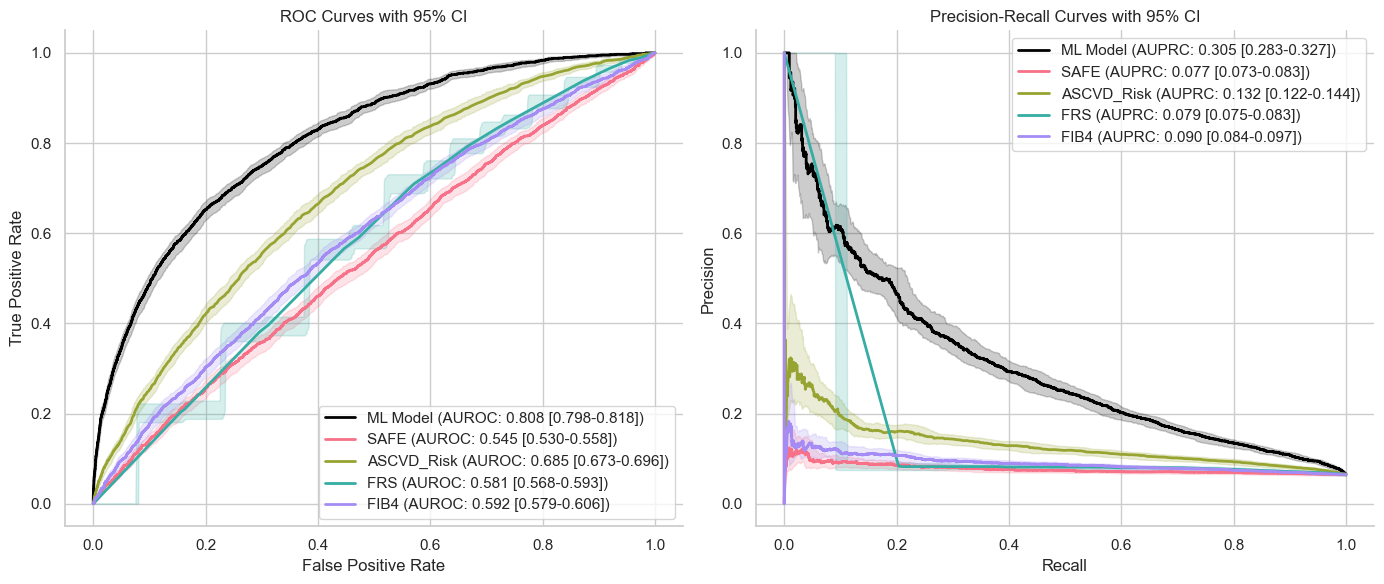

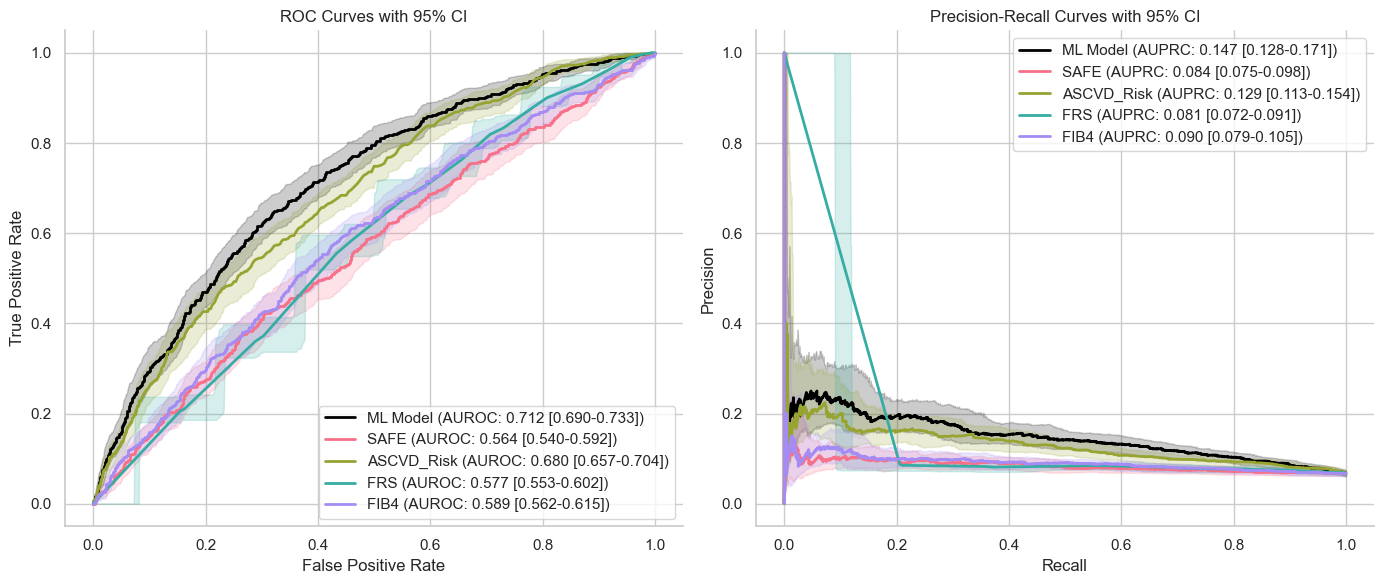

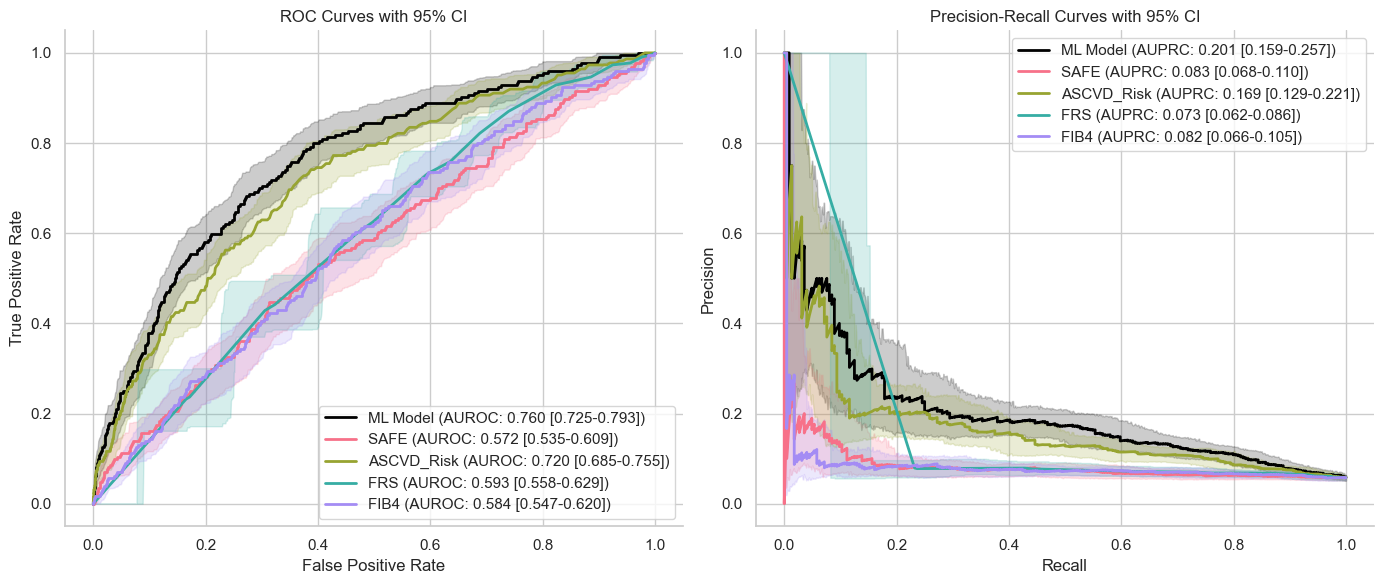

In [144]:
# Set Seaborn style
sns.set(style="whitegrid")
# Combined plot for all traditional scores with Seaborn styling
plot_combined_threshold_metrics(y_train, redefined_ukb_data2.query("region == 'England'").reset_index().loc[train_idx], ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_train_pred_proba)
plot_combined_threshold_metrics(y_val, redefined_ukb_data2.query("region == 'England'").reset_index().loc[val_idx], ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_val_pred_proba)
plot_combined_threshold_metrics(y_external, redefined_ukb_data2.query("region != 'England'").reset_index(), ['SAFE', 'ASCVD_Risk', 'FRS', 'FIB4'], y_external_pred_proba)

In [145]:
from sklearn.metrics import roc_curve

# =============================================
# Youden Index로 최적 cutoff 산출
# =============================================
def find_optimal_cutoff(y_true, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    youden = tpr - fpr
    optimal_idx = np.argmax(youden)
    return thresholds[optimal_idx], youden[optimal_idx]

# Training set에서 cutoff 결정 (validation/test에 동일 적용)
optimal_cutoff, youden_value = find_optimal_cutoff(y_train.values, pred_train_cal)
print(f"Optimal cutoff (Youden): {optimal_cutoff:.4f}")
print(f"Youden index: {youden_value:.4f}")


# =============================================
# 수정된 metrics 함수 (cutoff 반영)
# =============================================
def all_metrics_with_ci(y_true, y_pred_prob, threshold, n_boot=1000, seed=42):
    np.random.seed(seed)
    y_pred = (y_pred_prob >= threshold).astype(int)
    
    point = {
        'accuracy': accuracy_score(y_true, y_pred),
        'auroc': roc_auc_score(y_true, y_pred_prob),
        'auprc': average_precision_score(y_true, y_pred_prob),
        'sensitivity': recall_score(y_true, y_pred),
        'specificity': recall_score(y_true, y_pred, pos_label=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred),
    }
    
    boot_results = {k: [] for k in point.keys()}
    n = len(y_true)
    
    for _ in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        y_t = y_true[idx]
        y_pp = y_pred_prob[idx]
        y_p = (y_pp >= threshold).astype(int)
        
        if len(np.unique(y_t)) < 2:
            continue
        try:
            boot_results['accuracy'].append(accuracy_score(y_t, y_p))
            boot_results['auroc'].append(roc_auc_score(y_t, y_pp))
            boot_results['auprc'].append(average_precision_score(y_t, y_pp))
            boot_results['sensitivity'].append(recall_score(y_t, y_p))
            boot_results['specificity'].append(recall_score(y_t, y_p, pos_label=0))
            boot_results['precision'].append(precision_score(y_t, y_p, zero_division=0))
            boot_results['f1'].append(f1_score(y_t, y_p))
        except:
            continue
    
    result = {}
    for k in point.keys():
        result[k] = {
            'value': point[k],
            'ci': (np.percentile(boot_results[k], 2.5), 
                   np.percentile(boot_results[k], 97.5))
        }
    return result


# --- 실행 (Youden cutoff 적용) ---
print("=" * 90)
print(f"Table 2: M-CARD AI Performance Metrics (cutoff={optimal_cutoff:.4f})")
print("=" * 90)

for name, y, p in [
    ('Train', y_train.values, pred_train_cal),
    ('Validation', y_val.values, pred_val_cal),
    ('Test', y_external.values, pred_ext_cal),
]:
    r = all_metrics_with_ci(y, p, threshold=optimal_cutoff)
    print(f"\n--- {name} ---")
    for metric in ['accuracy', 'auroc', 'auprc', 'sensitivity', 'specificity', 'precision', 'f1']:
        v = r[metric]
        print(f"  {metric:>13s}: {v['value']:.4f} ({v['ci'][0]:.4f}–{v['ci'][1]:.4f})")

Optimal cutoff (Youden): 0.0693
Youden index: 0.4540
Table 2: M-CARD AI Performance Metrics (cutoff=0.0693)

--- Train ---
       accuracy: 0.7823 (0.7776–0.7870)
          auroc: 0.8079 (0.7979–0.8189)
          auprc: 0.3052 (0.2843–0.3276)
    sensitivity: 0.6635 (0.6424–0.6856)
    specificity: 0.7905 (0.7859–0.7955)
      precision: 0.1808 (0.1725–0.1908)
             f1: 0.2841 (0.2727–0.2976)

--- Validation ---
       accuracy: 0.7632 (0.7541–0.7731)
          auroc: 0.7118 (0.6871–0.7342)
          auprc: 0.1472 (0.1286–0.1716)
    sensitivity: 0.4990 (0.4523–0.5420)
    specificity: 0.7822 (0.7731–0.7921)
      precision: 0.1416 (0.1247–0.1578)
             f1: 0.2206 (0.1968–0.2435)

--- Test ---
       accuracy: 0.7861 (0.7740–0.7990)
          auroc: 0.7596 (0.7285–0.7905)
          auprc: 0.2008 (0.1568–0.2537)
    sensitivity: 0.5804 (0.5175–0.6439)
    specificity: 0.7987 (0.7867–0.8118)
      precision: 0.1501 (0.1263–0.1741)
             f1: 0.2385 (0.2047–0.2716)


In [174]:
import tableone

In [175]:
print(tableone.__version__)

0.9.6


In [176]:
import numpy as np
from sklearn.metrics import roc_auc_score

def calculate_auroc(y_true, y_pred):
    return roc_auc_score(y_true, y_pred)


def bootstraping(bootstrap_iterations, data, y_true, idx, y_pred_proba):
    if idx is None:
        y_true = y_true
        y_pred1 = y_pred_proba
        y_pred2 = data.ASCVD_Risk.to_numpy()
        y_true_reidx = y_true.reset_index(drop=True)

    else:
        y_true = y_true
        y_pred1 = y_pred_proba
        y_pred2 = data.loc[idx].ASCVD_Risk.to_numpy()
        y_true_reidx = y_true.reset_index(drop=True)

    
    auroc_diffs = []  # Initialize as a list
    for i in range(bootstrap_iterations):
        # 데이터 샘플링
        indices = np.random.randint(0, len(y_true), size=15000)
        sampled_y_true = y_true_reidx[indices]
        sampled_y_pred1 = y_pred1[indices]
        sampled_y_pred2 = y_pred2[indices]

        # AUROC 차이 계산
        auroc_diff = calculate_auroc(sampled_y_true, sampled_y_pred1) - calculate_auroc(sampled_y_true, sampled_y_pred2)
        auroc_diffs.append(auroc_diff)  # Append to the list

    # Calculate the 95% confidence interval
    auroc_diffs = np.array(auroc_diffs)  # Convert list to NumPy array
    lower_bound = np.percentile(auroc_diffs, 2.5)
    upper_bound = np.percentile(auroc_diffs, 97.5)
    
    return auroc_diffs, lower_bound, upper_bound



In [177]:
diffs, lb, ub = bootstraping(1000, ukb_masld2.query("region == 'England'").reset_index(), y_true=y_train, idx=train_idx, y_pred_proba=y_train_pred_proba)
# 결과 출력
print("AUROC Difference: {:.3f}".format(np.mean(diffs)))
print("95% Confidence Interval: ({:.3f}, {:.3f})".format(lb, ub))

AUROC Difference: 0.123
95% Confidence Interval: (0.112, 0.134)


In [178]:
diffs, lb, ub = bootstraping(1000, ukb_masld2.query("region == 'England'").reset_index(), y_true=y_val, idx=val_idx, y_pred_proba=y_val_pred_proba)
# 결과 출력
print("AUROC Difference: {:.3f}".format(np.mean(diffs)))
print("95% Confidence Interval: ({:.3f}, {:.3f})".format(lb, ub))

AUROC Difference: 0.031
95% Confidence Interval: (0.020, 0.042)


In [179]:
diffs, lb, ub = bootstraping(1000, ukb_masld2.query("region != 'England'").reset_index(), y_true=y_external, idx=None, y_pred_proba=y_external_pred_proba)
# 결과 출력
print("AUROC Difference: {:.3f}".format(np.mean(diffs)))
print("95% Confidence Interval: ({:.3f}, {:.3f})".format(lb, ub))

AUROC Difference: 0.040
95% Confidence Interval: (0.028, 0.052)


In [110]:
from tableone import TableOne

In [113]:
iecv_table = ukb_data2.copy()

In [114]:
iecv_table['dev'] = '0'
condit = (iecv_table['region'] == 'England')
iecv_table.loc[condit, 'dev'] = '1'

In [115]:
columns = ['ethnics', 'Sex', 'Waist', 'smoke_status', 'Past_tobacco',
       'Diastolic0', 'Systolic0', 'BMI', 'Platelet_count', 'Age', 
       'FIB4', 'FLI', 'BP_treated', 'DM', 'SAFE', 'ASCVD_Risk', 'FRS',
       'Albumin', 'Alkaline_phosphatase', 'Alanine_aminotransferase',
       'Apolipoprotein_A', 'Apolipoprotein_B', 'Aspartate_aminotransferase',
       'Direct bilirubin', 'Urea', 'Calcium', 'Cholesterol', 'Creatinine',
       'C-reactive_protein', 'Cystatin_C', 'Gamma_glutamyltransferase',
       'Glucose', 'HbA1c', 'HDL', 'IGF-1', 'LDL_direct', 'Lipoprotein_A',
       'Oestradiol', 'Phosphate', 'Rheumatoid_factor', 'SHBG',
       'Total_bilirubin', 'Testosterone', 'Total_protein', 'Triglycerides',
       'Urate', 'Vitamin_D', 'hand_grip_left','hand_grip_right','outcome', 'Dyslipidemia', 'MI_bi', 'STROKE_bi',
       'STEMI_bi', 'NSTEMI_bi', 'ISCHAEMIC_bi', 'INTRACEREBRAL_HEMO_bi',
       'SUBARACHNOID_HEMO_bi', 'cardiac_death', 'NAFLD', 'MASLD']

categorical = ['ethnics', 'Sex', 'smoke_status', 'Past_tobacco','BP_treated', 'DM','outcome', 'Dyslipidemia', 'MI_bi', 'STROKE_bi',
       'STEMI_bi', 'NSTEMI_bi', 'ISCHAEMIC_bi', 'INTRACEREBRAL_HEMO_bi',
       'SUBARACHNOID_HEMO_bi', 'cardiac_death', 'NAFLD', 'MASLD']

In [116]:
columns = ['ethnics', 'Sex', 'Waist', 'smoke_status', 'Past_tobacco',
       'Diastolic0', 'Systolic0', 'BMI', 'Platelet_count', 'Age', 
       'FIB4', 'FLI', 'BP_treated', 'DM', 'SAFE', 'ASCVD_Risk', 'FRS',
       'Albumin', 'Alkaline_phosphatase', 'Alanine_aminotransferase',
       'Apolipoprotein_A', 'Apolipoprotein_B', 'Aspartate_aminotransferase',
       'Direct bilirubin', 'Urea', 'Calcium', 'Cholesterol', 'Creatinine',
       'C-reactive_protein', 'Cystatin_C', 'Gamma_glutamyltransferase',
       'Glucose', 'HbA1c', 'HDL', 'IGF-1', 'LDL_direct', 'Lipoprotein_A',
       'Oestradiol', 'Phosphate', 'Rheumatoid_factor', 'SHBG',
       'Total_bilirubin', 'Testosterone', 'Total_protein', 'Triglycerides',
       'Urate', 'Vitamin_D', 'hand_grip_left','hand_grip_right', 'outcome']

categorical = ['ethnics', 'Sex', 'smoke_status','BP_treated', 'DM', 'outcome']

In [117]:
columns = set(columns) - set(['Phosphate', 'Oestradiol', 'Apolipoprotein_B', 'Alkaline_phosphatase', 'Apolipoprotein_A', 'Direct bilirubin', 'Vitamin_D', 'Past_tobacco', 'Urea', 'FLI', 'Rheumatoid_factor', 'Cystatin_C', 'Lipoprotein_A', 'IGF-1', 'Urate', 'SHBG', 'Testosterone'])
columns = list(columns)

In [119]:
tb = TableOne(iecv_table, columns=columns, categorical=categorical, groupby='dev', pval=True)

In [120]:
tb

Grouped by dev                                                     
                                                  Missing        Overall              0              1 P-Value
n                                                                  39691           3881          35810        
Total_bilirubin, mean (SD)                              8      0.5 (0.2)      0.5 (0.2)      0.5 (0.2)   0.070
FIB4, mean (SD)                                         0      1.3 (1.5)      1.2 (0.6)      1.3 (1.6)  <0.001
Calcium, mean (SD)                                     23      9.5 (0.4)      9.5 (0.4)      9.5 (0.4)  <0.001
Glucose, mean (SD)                                     35   100.2 (35.0)    98.5 (35.1)   100.4 (34.9)   0.002
HDL, mean (SD)                                          0    45.8 (10.3)    46.0 (10.4)    45.8 (10.3)   0.223
BP_treated, n (%)                     0                     32811 (82.7)    3146 (81.1)   29665 (82.8)   0.006
                                      1                      6880 (17.3)     735 (18.9)    6145 (17.2)        
Gamma_glutamyltransferase, mean (SD)                    0    66.6 (65.8)    71.3 (68.8)    66.0 (65.5)  <0.001
Triglycerides, mean (SD)                                0  248.9 (122.8)  252.1 (121.7)  248.5 (122.9)   0.085
SAFE, mean (SD)                                         0    58.2 (79.7)    59.7 (77.2)    58.0 (80.0)   0.181
smoke_status, n (%)                   0.0                   19542 (49.2)    1860 (47.9)   17682 (49.4)  <0.001
                                      1.0                   15743 (39.7)    1503 (38.7)   14240 (39.8)        
                                      2.0                    4357 (11.0)     516 (13.3)    3841 (10.7)        
                                      None                      49 (0.1)        2 (0.1)       47 (0.1)        
HbA1c, mean (SD)                                     1946      5.7 (0.9)      5.7 (0.9)      5.7 (0.9)   0.061
Diastolic0, mean (SD)                                   0    87.8 (10.1)     89.0 (9.9)    87.7 (10.1)  <0.001
ASCVD_Risk, mean (SD)                                   0     11.6 (8.9)     11.5 (8.9)     11.6 (8.8)   0.461
Waist, mean (SD)                                        0    110.5 (9.7)    109.5 (9.6)    110.6 (9.7)  <0.001
Aspartate_aminotransferase, mean (SD)                   0    30.4 (13.5)    30.5 (13.5)    30.4 (13.5)   0.383
ethnics, n (%)                        1                     37671 (94.9)    3805 (98.0)   33866 (94.6)  <0.001
                                      2                        238 (0.6)       21 (0.5)      217 (0.6)        
                                      3                        638 (1.6)       20 (0.5)      618 (1.7)        
                                      4                        710 (1.8)       18 (0.5)      692 (1.9)        
                                      5                         21 (0.1)        0 (0.0)       21 (0.1)        
                                      6                        364 (0.9)       15 (0.4)      349 (1.0)        
                                      nan                       49 (0.1)        2 (0.1)       47 (0.1)        
Systolic0, mean (SD)                                    0   145.9 (18.2)   147.0 (18.5)   145.8 (18.1)  <0.001
Age, mean (SD)                                          0     56.1 (7.7)     55.5 (7.6)     56.2 (7.7)  <0.001
FRS, mean (SD)                                          0     16.9 (8.8)     17.3 (8.7)     16.8 (8.8)   0.002
hand_grip_right, mean (SD)                            139    34.4 (12.2)    35.8 (12.3)    34.2 (12.2)  <0.001
DM, n (%)                             0                     34145 (86.0)    3390 (87.3)   30755 (85.9)   0.013
                                      1                      5546 (14.0)     491 (12.7)    5055 (14.1)        
LDL_direct, mean (SD)                                   0   141.2 (35.2)   142.2 (34.4)   141.1 (35.3)   0.056
Cholesterol, mean (SD)                         

In [121]:
tb.to_excel('./[2603FN]Table_1.xlsx')